In [1]:
import mlflow
import pandas as pd
from sklearn.metrics import accuracy_score, precision_score
from xgboost import XGBClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier
import numpy as np
from itertools import product
import matplotlib.pyplot as plt
from sklearn.model_selection import TimeSeriesSplit
from sklearn.preprocessing import StandardScaler
from collections import defaultdict

import sys
sys.path.insert(0, "../../run")
from const import REPO_PATH
from experiment_config import TRAINGING_CONFIG

sys.path.insert(1, f"{REPO_PATH}")
from src.model.experiment_utils import *
from src.model.model_utils import *
from src.model.models import MLPWithDropout, MLPWithDropoutBN

In [2]:
features_path = f"{TRAINGING_CONFIG['features_path']}/all_combined_features_2017-24.csv"
output_dir = f"{REPO_PATH}/models/ml_models"

In [3]:
seasons=sorted(TRAINGING_CONFIG['seasons'])
target_dfs=[pd.read_csv(f"{TRAINGING_CONFIG['processed_data_path']}/{season}/all_target_df.csv") for season in seasons[1:]]
for df in target_dfs:
    df['date']= pd.to_datetime(df['date'])
target_df = pd.concat(target_dfs, ignore_index=True)
target_columns=target_df.drop(columns=TRAINGING_CONFIG['key_columns']).columns.tolist()

In [4]:
feature_df = pd.read_csv(features_path)
feature_df['date']= pd.to_datetime(feature_df['date'])
feature_df, target_df=align_on_keys(feature_df, target_df, TRAINGING_CONFIG['key_columns'])

In [5]:
param_grid = {
    'model_params.hidden_layers': [(512, 128, 128, 128, 64), (256, 128, 128, 64)],
    'model_params.activation': ['relu'],
    'model_params.dropout_rate': [0.1],
    'learning_rate': [0.00001, 0.0001],
    'batch_size': [64, 128],
    'epochs': [2000]
}


In [6]:
feature_df.fillna(-1, inplace=True)

In [7]:
numeric_cols = feature_df.select_dtypes(include=[np.number]).columns

scaler = StandardScaler()
feature_df[numeric_cols] = scaler.fit_transform(feature_df[numeric_cols])

In [8]:
feature_df.shape

(2280, 2729)

2025/07/25 16:03:30 INFO mlflow.tracking.fluent: Experiment with name 'mlflow_distribution_ts_5fold_0.5train_2017-24_lag_target_norm' does not exist. Creating a new experiment.


Training MLPwithDropoutBN on home_goals with param grid: {'model_params.hidden_layers': [(512, 128, 128, 128, 64), (256, 128, 128, 64)], 'model_params.activation': ['relu'], 'model_params.dropout_rate': [0.1], 'learning_rate': [1e-05, 0.0001], 'batch_size': [64, 128], 'epochs': [2000]}
Using range-based class conversion with range: (0, 5)
Training fold 1/5 with params: {'model_params.hidden_layers': (512, 128, 128, 128, 64), 'model_params.activation': 'relu', 'model_params.dropout_rate': 0.1, 'learning_rate': 1e-05, 'batch_size': 64, 'epochs': 2000}
[TorchWrapper] Using device: mps


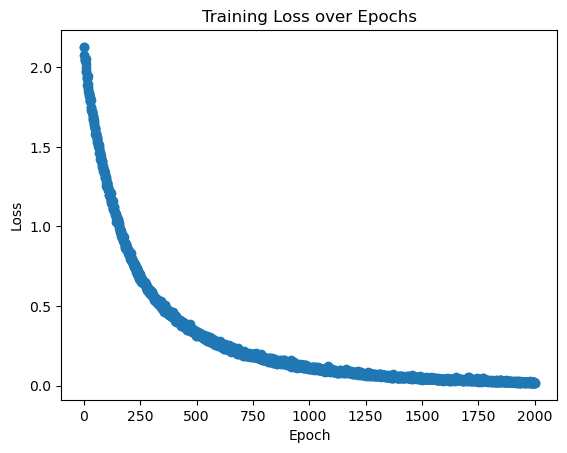

Final training loss: 0.018123783900985242
Training fold 2/5 with params: {'model_params.hidden_layers': (512, 128, 128, 128, 64), 'model_params.activation': 'relu', 'model_params.dropout_rate': 0.1, 'learning_rate': 1e-05, 'batch_size': 64, 'epochs': 2000}
[TorchWrapper] Using device: mps


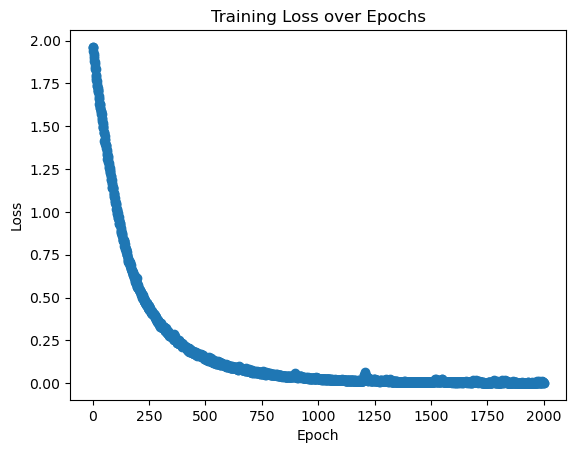

Final training loss: 0.0030486192159376473
Training fold 3/5 with params: {'model_params.hidden_layers': (512, 128, 128, 128, 64), 'model_params.activation': 'relu', 'model_params.dropout_rate': 0.1, 'learning_rate': 1e-05, 'batch_size': 64, 'epochs': 2000}
[TorchWrapper] Using device: mps


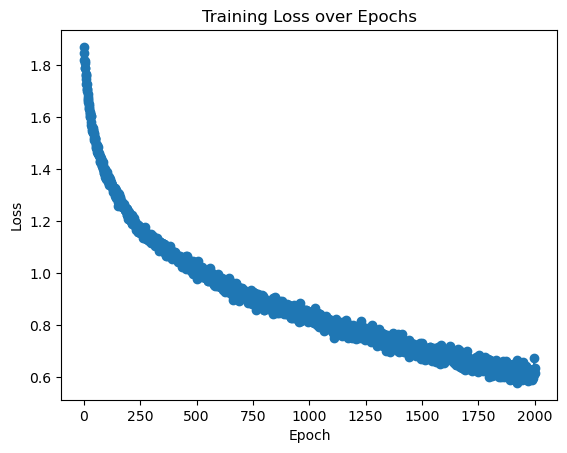

Final training loss: 0.6335309720643547
Training fold 4/5 with params: {'model_params.hidden_layers': (512, 128, 128, 128, 64), 'model_params.activation': 'relu', 'model_params.dropout_rate': 0.1, 'learning_rate': 1e-05, 'batch_size': 64, 'epochs': 2000}
[TorchWrapper] Using device: mps


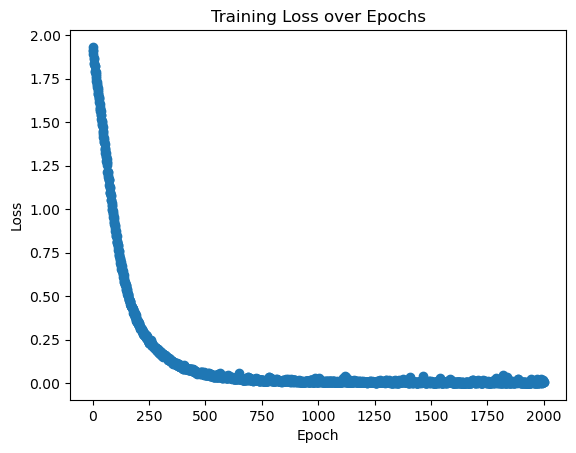

Final training loss: 0.004917815559113409
Training fold 5/5 with params: {'model_params.hidden_layers': (512, 128, 128, 128, 64), 'model_params.activation': 'relu', 'model_params.dropout_rate': 0.1, 'learning_rate': 1e-05, 'batch_size': 64, 'epochs': 2000}
[TorchWrapper] Using device: mps


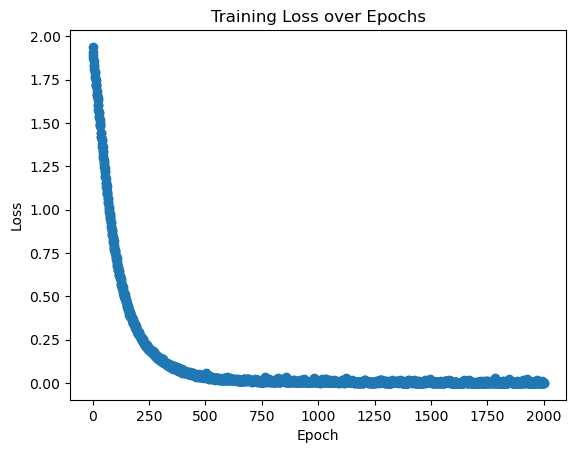

Final training loss: 0.0023071917540486357
[TorchWrapper] Using device: mps


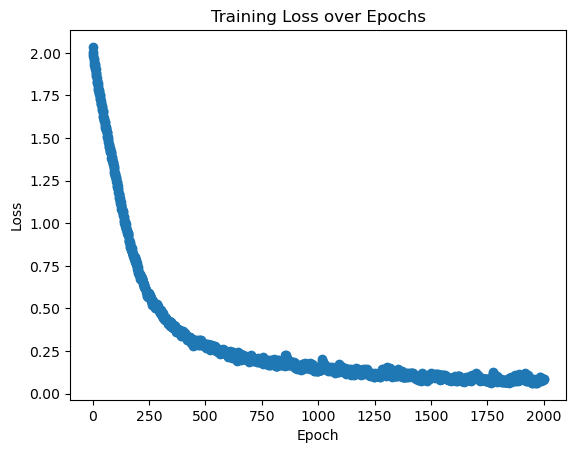

Final training loss: 0.08349761779312967
{'home_goals_train_accuracy': 0.9826510721247563, 'home_goals_train_precision': 0.9558667201524343, 'home_goals_valid_accuracy': 0.28538011695906434, 'home_goals_valid_precision': 0.15495162891979702, 'home_goals_test_accuracy': 0.24561403508771928, 'home_goals_test_precision': 0.1580788259359688, 'home_goals_train_lte_0_accuracy': 0.9937621832358674, 'home_goals_train_lte_0_accuracy_std': 0.012475633528265107, 'home_goals_train_lte_0_precision': 0.979054054054054, 'home_goals_train_lte_0_precision_std': 0.04189189189189189, 'home_goals_train_gt_0_accuracy': 0.9937621832358674, 'home_goals_train_gt_0_accuracy_std': 0.012475633528265107, 'home_goals_train_gt_0_precision': 0.9997260273972604, 'home_goals_train_gt_0_precision_std': 0.0005479452054794721, 'home_goals_train_gt_1_accuracy': 0.9910331384015596, 'home_goals_train_gt_1_accuracy_std': 0.017933723196881114, 'home_goals_train_gt_1_precision': 0.9989417989417989, 'home_goals_train_gt_1_preci

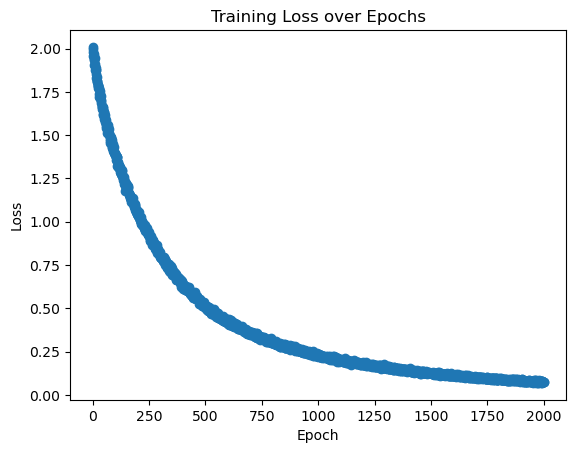

Final training loss: 0.07307044281597026
Training fold 2/precision with params: {'model_params.hidden_layers': (512, 128, 128, 128, 64), 'model_params.activation': 'relu', 'model_params.dropout_rate': 0.1, 'learning_rate': 1e-05, 'batch_size': 128, 'epochs': 2000}
[TorchWrapper] Using device: mps


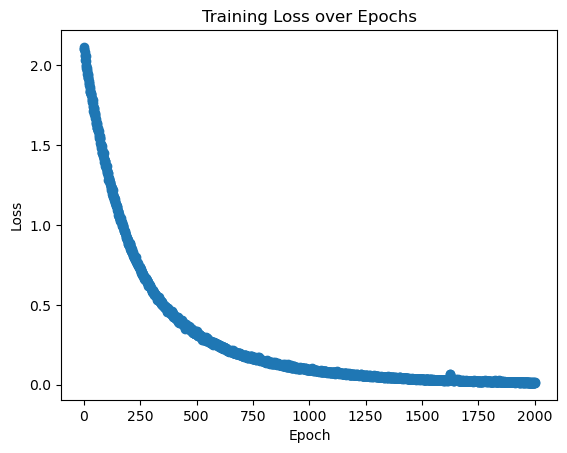

Final training loss: 0.012715824525694402
Training fold 3/precision with params: {'model_params.hidden_layers': (512, 128, 128, 128, 64), 'model_params.activation': 'relu', 'model_params.dropout_rate': 0.1, 'learning_rate': 1e-05, 'batch_size': 128, 'epochs': 2000}
[TorchWrapper] Using device: mps


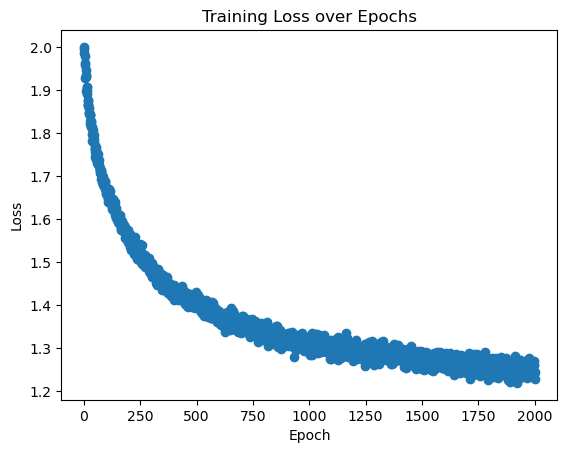

Final training loss: 1.2446973092607123
Training fold 4/precision with params: {'model_params.hidden_layers': (512, 128, 128, 128, 64), 'model_params.activation': 'relu', 'model_params.dropout_rate': 0.1, 'learning_rate': 1e-05, 'batch_size': 128, 'epochs': 2000}
[TorchWrapper] Using device: mps


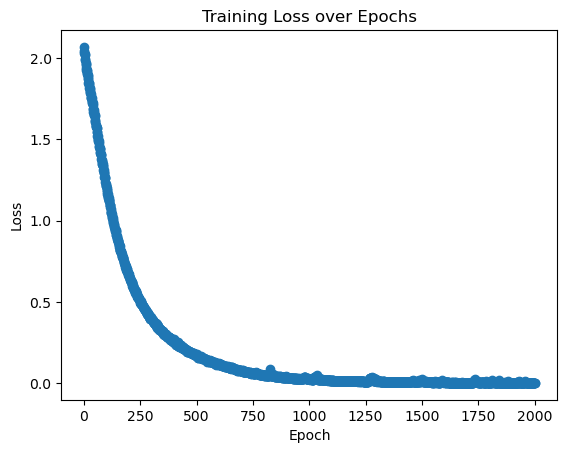

Final training loss: 0.0018916136778520736
Training fold 5/precision with params: {'model_params.hidden_layers': (512, 128, 128, 128, 64), 'model_params.activation': 'relu', 'model_params.dropout_rate': 0.1, 'learning_rate': 1e-05, 'batch_size': 128, 'epochs': 2000}
[TorchWrapper] Using device: mps


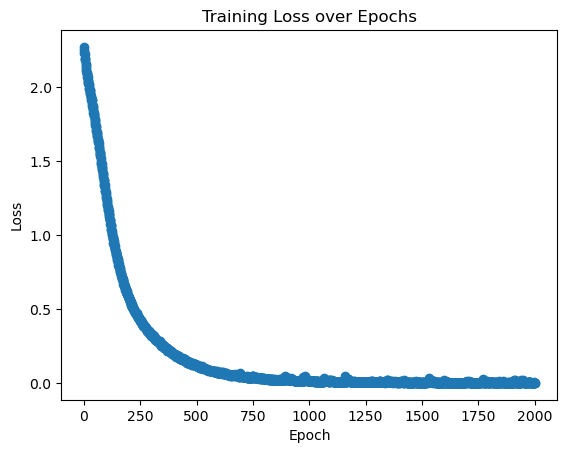

Final training loss: 0.00272581823366253
[TorchWrapper] Using device: mps


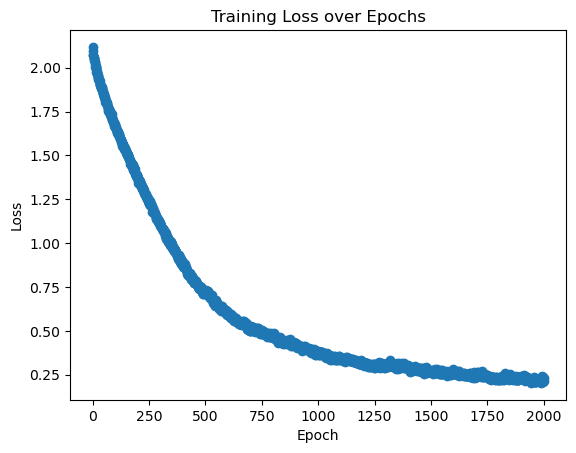

Final training loss: 0.21399522385402034
{'home_goals_train_accuracy': 0.9269005847953217, 'home_goals_train_precision': 0.8802065093196354, 'home_goals_valid_accuracy': 0.2608187134502924, 'home_goals_valid_precision': 0.1454258730584943, 'home_goals_test_accuracy': 0.2719298245614035, 'home_goals_test_precision': 0.17750449702504498, 'home_goals_train_lte_0_accuracy': 0.9709551656920077, 'home_goals_train_lte_0_accuracy_std': 0.05808966861598441, 'home_goals_train_lte_0_precision': 0.9407665505226481, 'home_goals_train_lte_0_precision_std': 0.11846689895470383, 'home_goals_train_gt_0_accuracy': 0.9709551656920077, 'home_goals_train_gt_0_accuracy_std': 0.05808966861598441, 'home_goals_train_gt_0_precision': 0.9826792963464139, 'home_goals_train_gt_0_precision_std': 0.03464140730717187, 'home_goals_train_gt_1_accuracy': 0.9528265107212477, 'home_goals_train_gt_1_accuracy_std': 0.09434697855750489, 'home_goals_train_gt_1_precision': 0.9754237288135593, 'home_goals_train_gt_1_precision_s

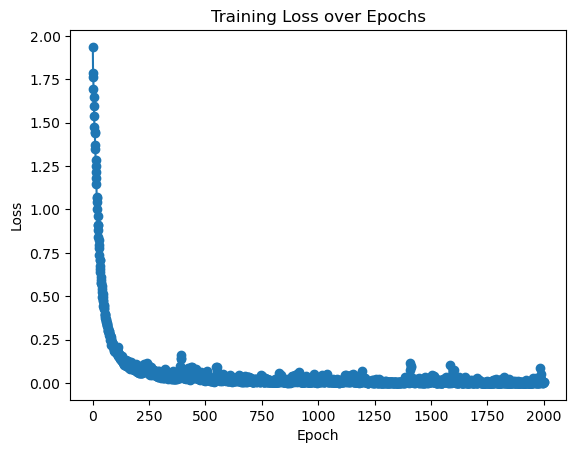

Final training loss: 0.0032682195687067437
Training fold 2/precision with params: {'model_params.hidden_layers': (512, 128, 128, 128, 64), 'model_params.activation': 'relu', 'model_params.dropout_rate': 0.1, 'learning_rate': 0.0001, 'batch_size': 64, 'epochs': 2000}
[TorchWrapper] Using device: mps


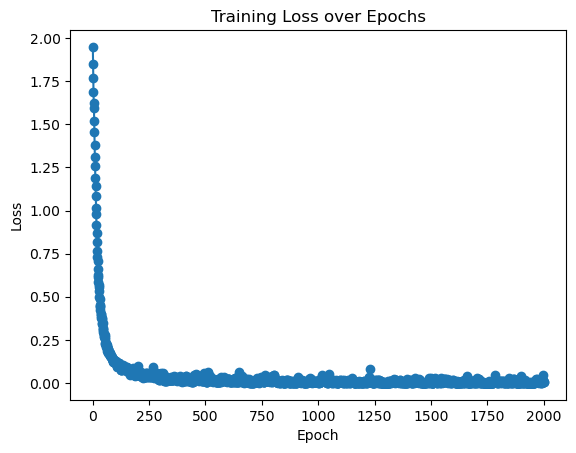

Final training loss: 0.008233361943537772
Training fold 3/precision with params: {'model_params.hidden_layers': (512, 128, 128, 128, 64), 'model_params.activation': 'relu', 'model_params.dropout_rate': 0.1, 'learning_rate': 0.0001, 'batch_size': 64, 'epochs': 2000}
[TorchWrapper] Using device: mps


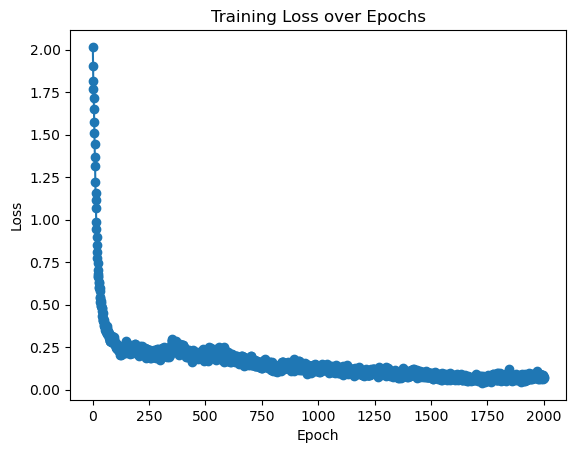

Final training loss: 0.0764027397070247
Training fold 4/precision with params: {'model_params.hidden_layers': (512, 128, 128, 128, 64), 'model_params.activation': 'relu', 'model_params.dropout_rate': 0.1, 'learning_rate': 0.0001, 'batch_size': 64, 'epochs': 2000}
[TorchWrapper] Using device: mps


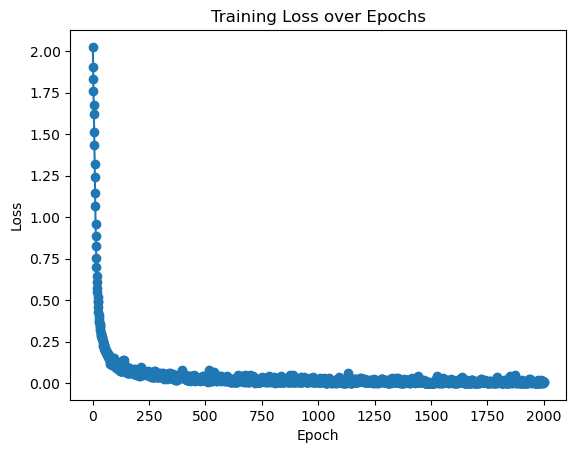

Final training loss: 0.008321654076050771
Training fold 5/precision with params: {'model_params.hidden_layers': (512, 128, 128, 128, 64), 'model_params.activation': 'relu', 'model_params.dropout_rate': 0.1, 'learning_rate': 0.0001, 'batch_size': 64, 'epochs': 2000}
[TorchWrapper] Using device: mps


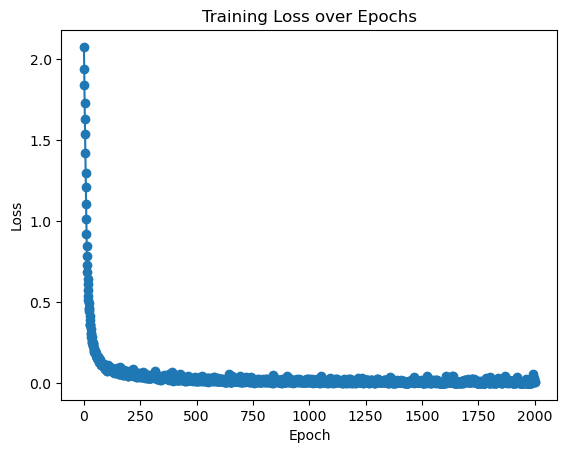

Final training loss: 0.0049238708240595475
[TorchWrapper] Using device: mps


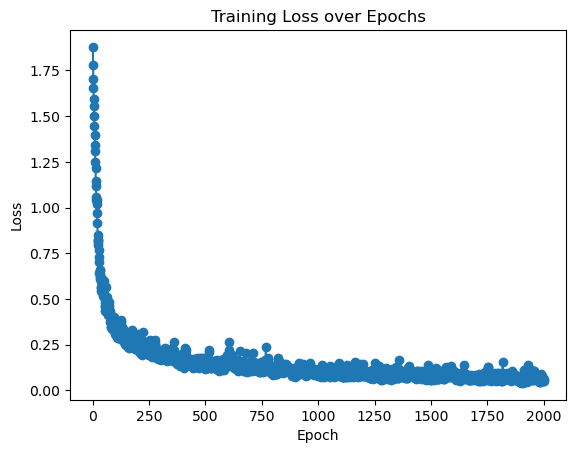

Final training loss: 0.0632451440971962
{'home_goals_train_accuracy': 1.0, 'home_goals_train_precision': 1.0, 'home_goals_valid_accuracy': 0.28011695906432743, 'home_goals_valid_precision': 0.16811250162021243, 'home_goals_test_accuracy': 0.2412280701754386, 'home_goals_test_precision': 0.18197183216337115, 'home_goals_train_lte_0_accuracy': 1.0, 'home_goals_train_lte_0_accuracy_std': 0.0, 'home_goals_train_lte_0_precision': 1.0, 'home_goals_train_lte_0_precision_std': 0.0, 'home_goals_train_gt_0_accuracy': 1.0, 'home_goals_train_gt_0_accuracy_std': 0.0, 'home_goals_train_gt_0_precision': 1.0, 'home_goals_train_gt_0_precision_std': 0.0, 'home_goals_train_gt_1_accuracy': 1.0, 'home_goals_train_gt_1_accuracy_std': 0.0, 'home_goals_train_gt_1_precision': 1.0, 'home_goals_train_gt_1_precision_std': 0.0, 'home_goals_train_gt_2_accuracy': 1.0, 'home_goals_train_gt_2_accuracy_std': 0.0, 'home_goals_train_gt_2_precision': 1.0, 'home_goals_train_gt_2_precision_std': 0.0, 'home_goals_train_gt_3_

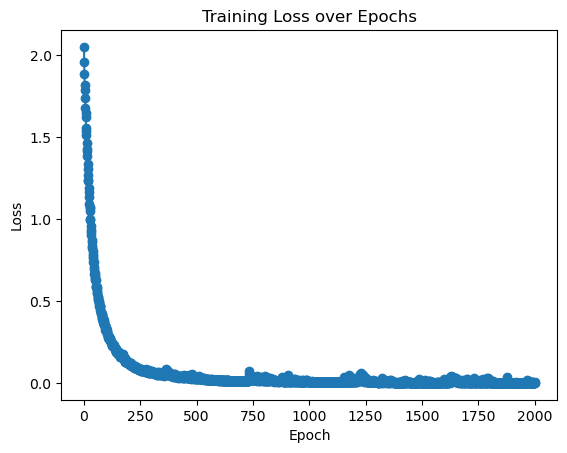

Final training loss: 0.0013154652759389221
Training fold 2/precision with params: {'model_params.hidden_layers': (512, 128, 128, 128, 64), 'model_params.activation': 'relu', 'model_params.dropout_rate': 0.1, 'learning_rate': 0.0001, 'batch_size': 128, 'epochs': 2000}
[TorchWrapper] Using device: mps


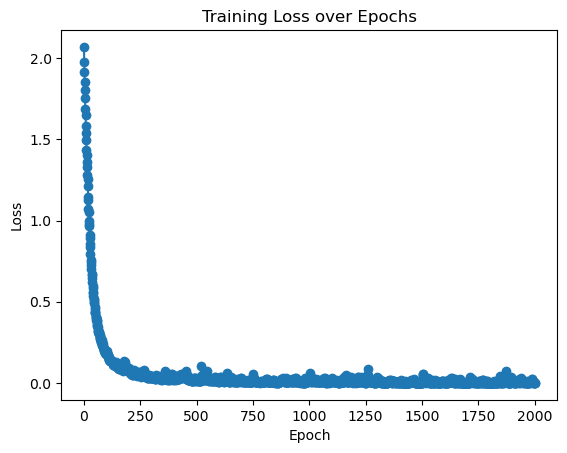

Final training loss: 0.0009556515945655386
Training fold 3/precision with params: {'model_params.hidden_layers': (512, 128, 128, 128, 64), 'model_params.activation': 'relu', 'model_params.dropout_rate': 0.1, 'learning_rate': 0.0001, 'batch_size': 128, 'epochs': 2000}
[TorchWrapper] Using device: mps


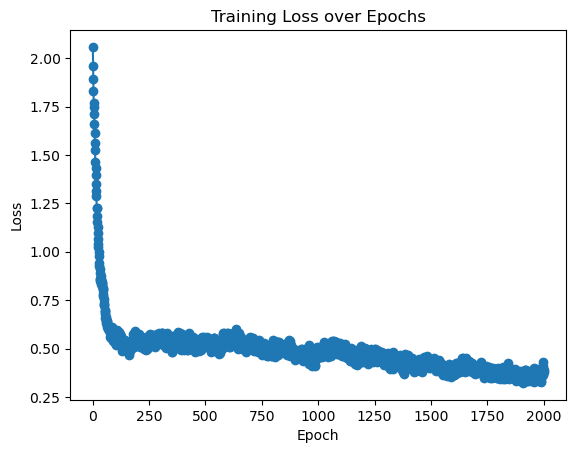

Final training loss: 0.3901538149422837
Training fold 4/precision with params: {'model_params.hidden_layers': (512, 128, 128, 128, 64), 'model_params.activation': 'relu', 'model_params.dropout_rate': 0.1, 'learning_rate': 0.0001, 'batch_size': 128, 'epochs': 2000}
[TorchWrapper] Using device: mps


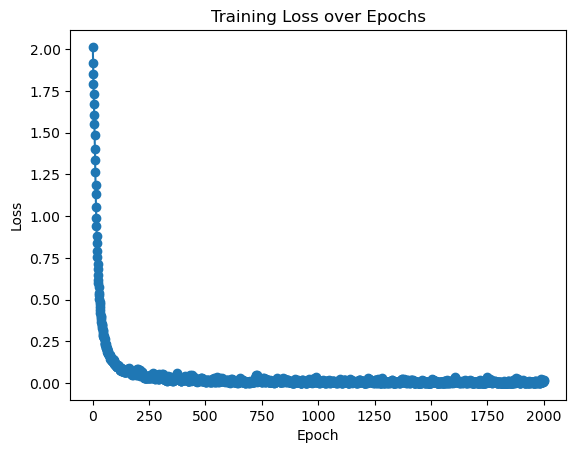

Final training loss: 0.01641838649854238
Training fold 5/precision with params: {'model_params.hidden_layers': (512, 128, 128, 128, 64), 'model_params.activation': 'relu', 'model_params.dropout_rate': 0.1, 'learning_rate': 0.0001, 'batch_size': 128, 'epochs': 2000}
[TorchWrapper] Using device: mps


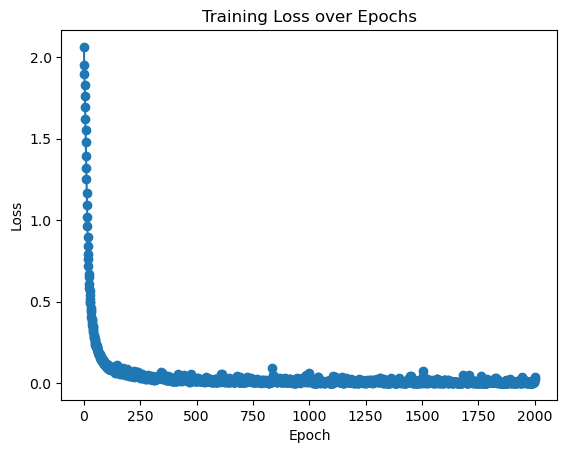

Final training loss: 0.024494362418806693
[TorchWrapper] Using device: mps


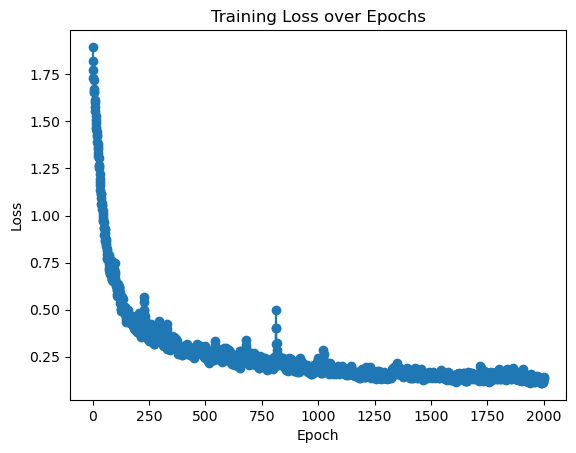

Final training loss: 0.13894440527083116
{'home_goals_train_accuracy': 0.989551656920078, 'home_goals_train_precision': 0.9619996376742286, 'home_goals_valid_accuracy': 0.2742690058479532, 'home_goals_valid_precision': 0.16603414997469096, 'home_goals_test_accuracy': 0.20175438596491227, 'home_goals_test_precision': 0.1330966341032621, 'home_goals_train_lte_0_accuracy': 0.9949317738791423, 'home_goals_train_lte_0_accuracy_std': 0.010136452241715421, 'home_goals_train_lte_0_precision': 0.9845070422535211, 'home_goals_train_lte_0_precision_std': 0.03098591549295775, 'home_goals_train_gt_0_accuracy': 0.9949317738791423, 'home_goals_train_gt_0_accuracy_std': 0.010136452241715421, 'home_goals_train_gt_0_precision': 0.998921832884097, 'home_goals_train_gt_0_precision_std': 0.002156334231805923, 'home_goals_train_gt_1_accuracy': 0.9926705653021444, 'home_goals_train_gt_1_accuracy_std': 0.012975839652373209, 'home_goals_train_gt_1_precision': 0.9972842181292887, 'home_goals_train_gt_1_precisio

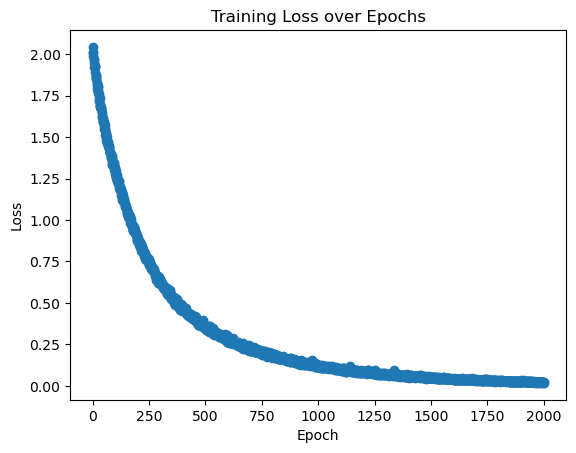

Final training loss: 0.020731021110948763
Training fold 2/precision with params: {'model_params.hidden_layers': (256, 128, 128, 64), 'model_params.activation': 'relu', 'model_params.dropout_rate': 0.1, 'learning_rate': 1e-05, 'batch_size': 64, 'epochs': 2000}
[TorchWrapper] Using device: mps


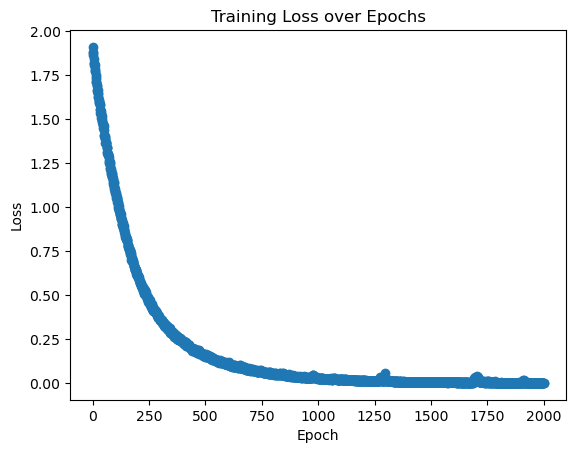

Final training loss: 0.002380715465249374
Training fold 3/precision with params: {'model_params.hidden_layers': (256, 128, 128, 64), 'model_params.activation': 'relu', 'model_params.dropout_rate': 0.1, 'learning_rate': 1e-05, 'batch_size': 64, 'epochs': 2000}
[TorchWrapper] Using device: mps


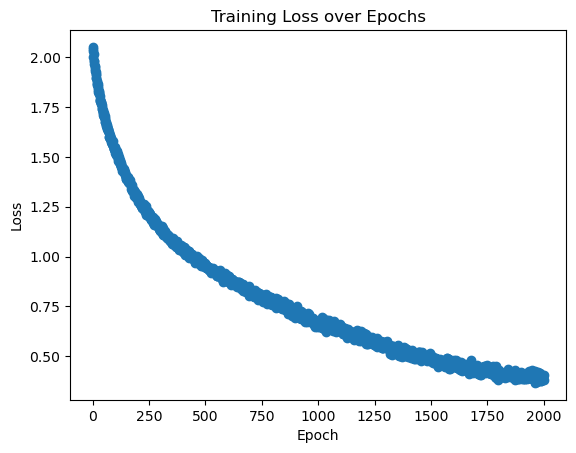

Final training loss: 0.40483048784802533
Training fold 4/precision with params: {'model_params.hidden_layers': (256, 128, 128, 64), 'model_params.activation': 'relu', 'model_params.dropout_rate': 0.1, 'learning_rate': 1e-05, 'batch_size': 64, 'epochs': 2000}
[TorchWrapper] Using device: mps


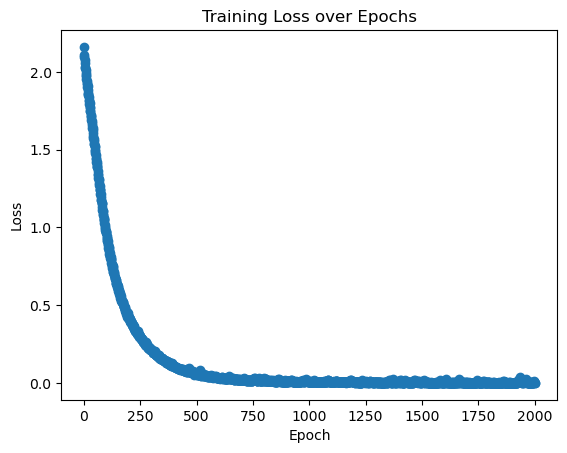

Final training loss: 0.0023845856225020007
Training fold 5/precision with params: {'model_params.hidden_layers': (256, 128, 128, 64), 'model_params.activation': 'relu', 'model_params.dropout_rate': 0.1, 'learning_rate': 1e-05, 'batch_size': 64, 'epochs': 2000}
[TorchWrapper] Using device: mps


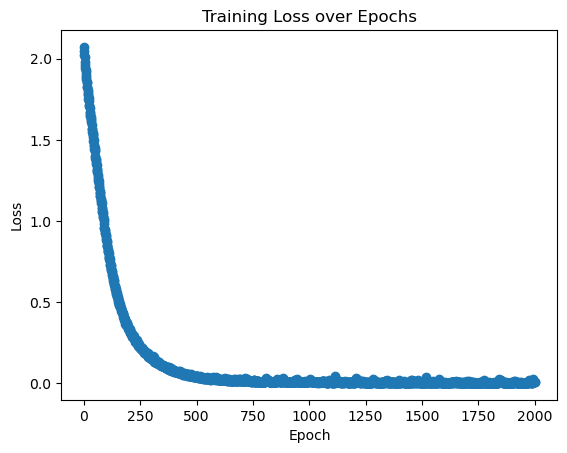

Final training loss: 0.0056698977244658425
[TorchWrapper] Using device: mps


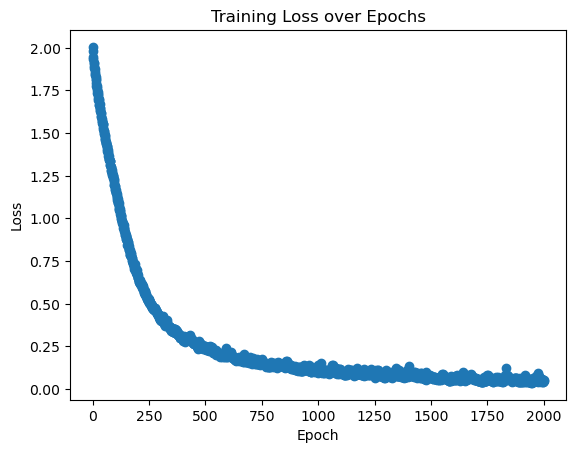

Final training loss: 0.050714486930337796
{'home_goals_train_accuracy': 0.9912280701754387, 'home_goals_train_precision': 0.9646142386954839, 'home_goals_valid_accuracy': 0.2783625730994152, 'home_goals_valid_precision': 0.158244414068066, 'home_goals_test_accuracy': 0.20175438596491227, 'home_goals_test_precision': 0.13500049614940993, 'home_goals_train_lte_0_accuracy': 0.996101364522417, 'home_goals_train_lte_0_accuracy_std': 0.007797270955165692, 'home_goals_train_lte_0_precision': 0.9866197183098592, 'home_goals_train_lte_0_precision_std': 0.0267605633802817, 'home_goals_train_gt_0_accuracy': 0.996101364522417, 'home_goals_train_gt_0_accuracy_std': 0.007797270955165692, 'home_goals_train_gt_0_precision': 0.9997304582210242, 'home_goals_train_gt_0_precision_std': 0.0005390835579514697, 'home_goals_train_gt_1_accuracy': 0.9962962962962962, 'home_goals_train_gt_1_accuracy_std': 0.007407407407407395, 'home_goals_train_gt_1_precision': 0.9990123456790123, 'home_goals_train_gt_1_precisio

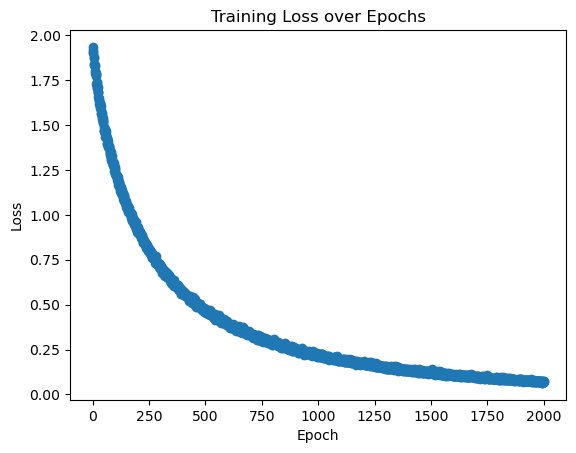

Final training loss: 0.07611376722479424
Training fold 2/precision with params: {'model_params.hidden_layers': (256, 128, 128, 64), 'model_params.activation': 'relu', 'model_params.dropout_rate': 0.1, 'learning_rate': 1e-05, 'batch_size': 128, 'epochs': 2000}
[TorchWrapper] Using device: mps


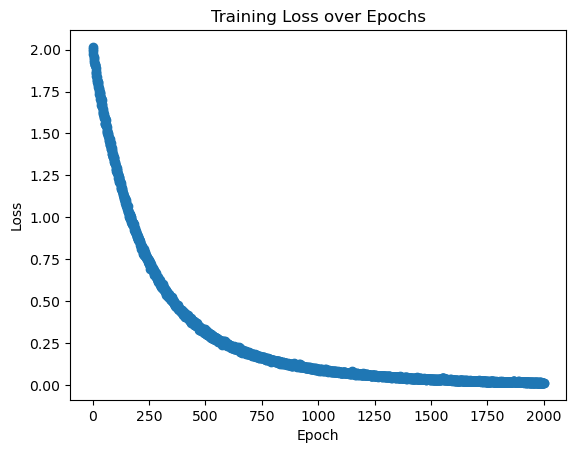

Final training loss: 0.012377972643800646
Training fold 3/precision with params: {'model_params.hidden_layers': (256, 128, 128, 64), 'model_params.activation': 'relu', 'model_params.dropout_rate': 0.1, 'learning_rate': 1e-05, 'batch_size': 128, 'epochs': 2000}
[TorchWrapper] Using device: mps


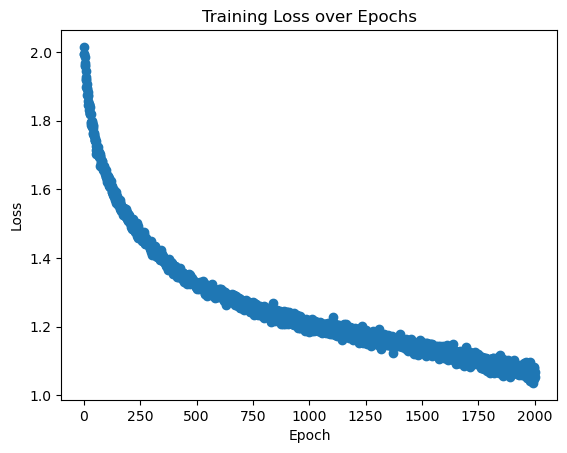

Final training loss: 1.069200517141331
Training fold 4/precision with params: {'model_params.hidden_layers': (256, 128, 128, 64), 'model_params.activation': 'relu', 'model_params.dropout_rate': 0.1, 'learning_rate': 1e-05, 'batch_size': 128, 'epochs': 2000}
[TorchWrapper] Using device: mps


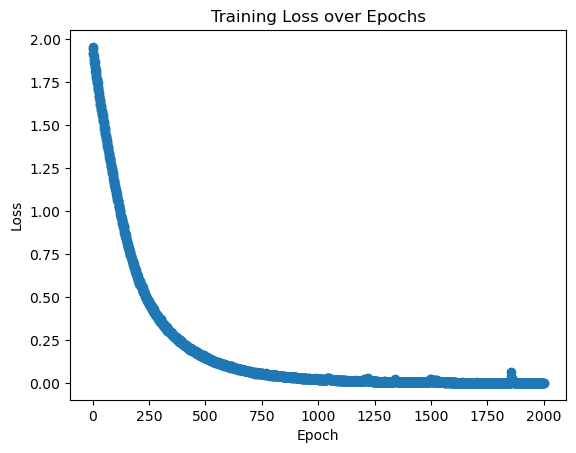

Final training loss: 0.0015661803200808272
Training fold 5/precision with params: {'model_params.hidden_layers': (256, 128, 128, 64), 'model_params.activation': 'relu', 'model_params.dropout_rate': 0.1, 'learning_rate': 1e-05, 'batch_size': 128, 'epochs': 2000}
[TorchWrapper] Using device: mps


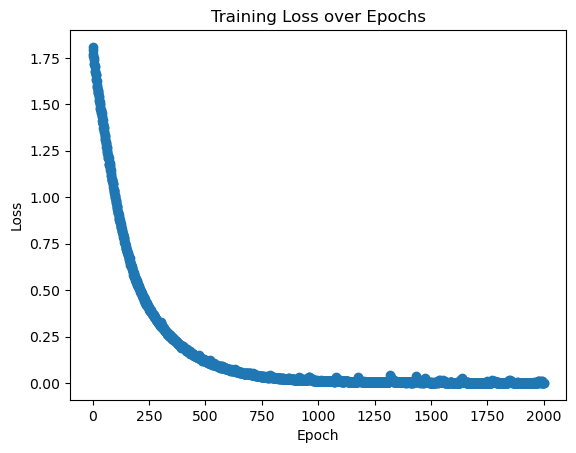

Final training loss: 0.0034197631351954756
[TorchWrapper] Using device: mps


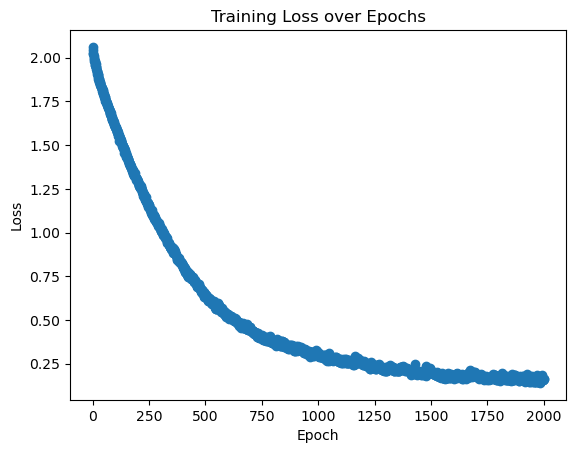

Final training loss: 0.16262540141334775
{'home_goals_train_accuracy': 0.9453021442495126, 'home_goals_train_precision': 0.9150726927440829, 'home_goals_valid_accuracy': 0.2625730994152047, 'home_goals_valid_precision': 0.19592518124757136, 'home_goals_test_accuracy': 0.19298245614035087, 'home_goals_test_precision': 0.13095704521850532, 'home_goals_train_lte_0_accuracy': 0.9766861598440546, 'home_goals_train_lte_0_accuracy_std': 0.04633583619823835, 'home_goals_train_lte_0_precision': 0.9497201980137134, 'home_goals_train_lte_0_precision_std': 0.0994373039290138, 'home_goals_train_gt_0_accuracy': 0.9766861598440546, 'home_goals_train_gt_0_accuracy_std': 0.04633583619823835, 'home_goals_train_gt_0_precision': 0.9874488403819918, 'home_goals_train_gt_0_precision_std': 0.02510231923601638, 'home_goals_train_gt_1_accuracy': 0.9593372319688109, 'home_goals_train_gt_1_accuracy_std': 0.08103345492475018, 'home_goals_train_gt_1_precision': 0.987603305785124, 'home_goals_train_gt_1_precision_s

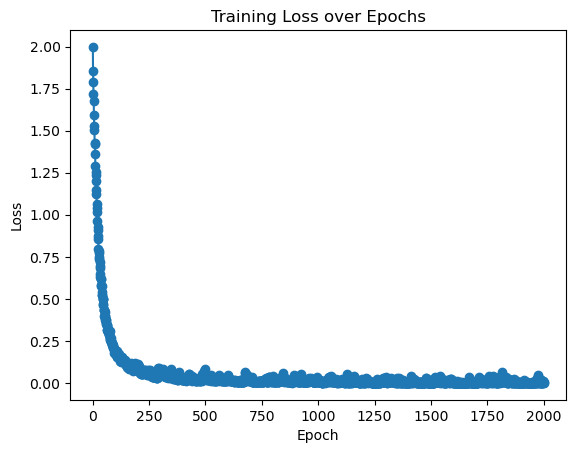

Final training loss: 0.003102424413602995
Training fold 2/precision with params: {'model_params.hidden_layers': (256, 128, 128, 64), 'model_params.activation': 'relu', 'model_params.dropout_rate': 0.1, 'learning_rate': 0.0001, 'batch_size': 64, 'epochs': 2000}
[TorchWrapper] Using device: mps


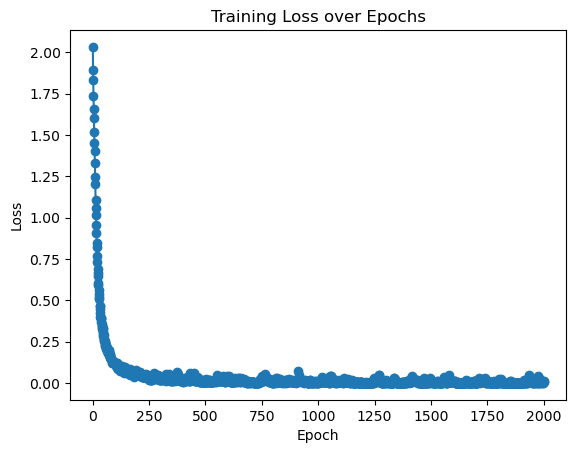

Final training loss: 0.00984283903210658
Training fold 3/precision with params: {'model_params.hidden_layers': (256, 128, 128, 64), 'model_params.activation': 'relu', 'model_params.dropout_rate': 0.1, 'learning_rate': 0.0001, 'batch_size': 64, 'epochs': 2000}
[TorchWrapper] Using device: mps


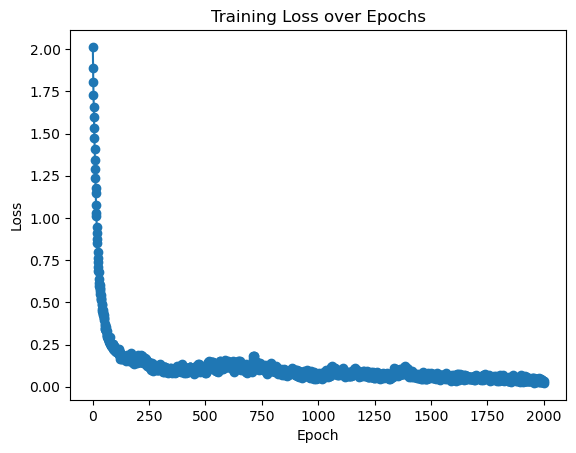

Final training loss: 0.03171484695191969
Training fold 4/precision with params: {'model_params.hidden_layers': (256, 128, 128, 64), 'model_params.activation': 'relu', 'model_params.dropout_rate': 0.1, 'learning_rate': 0.0001, 'batch_size': 64, 'epochs': 2000}
[TorchWrapper] Using device: mps


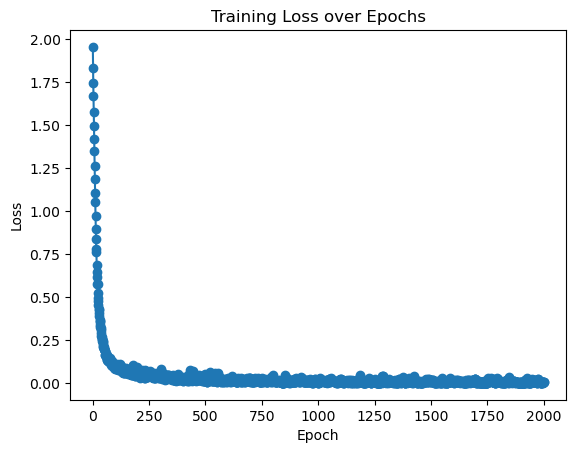

Final training loss: 0.004831009485884107
Training fold 5/precision with params: {'model_params.hidden_layers': (256, 128, 128, 64), 'model_params.activation': 'relu', 'model_params.dropout_rate': 0.1, 'learning_rate': 0.0001, 'batch_size': 64, 'epochs': 2000}
[TorchWrapper] Using device: mps


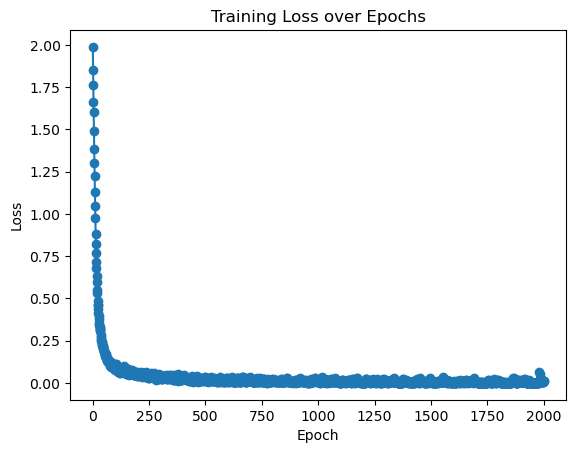

Final training loss: 0.012757785657450709
[TorchWrapper] Using device: mps


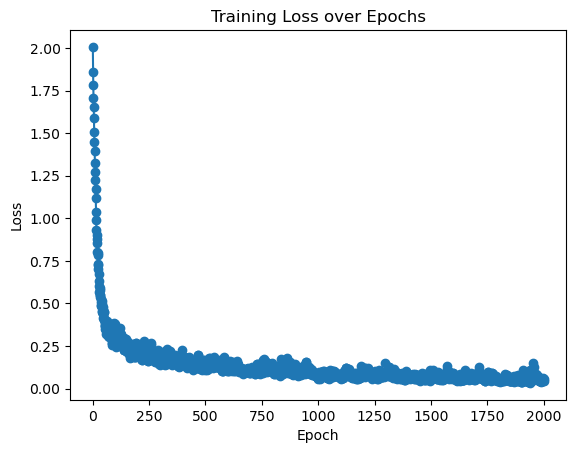

Final training loss: 0.054196937710453426
{'home_goals_train_accuracy': 0.9990350877192983, 'home_goals_train_precision': 0.994815158733363, 'home_goals_valid_accuracy': 0.283625730994152, 'home_goals_valid_precision': 0.17248163699340532, 'home_goals_test_accuracy': 0.21052631578947367, 'home_goals_test_precision': 0.141341132412561, 'home_goals_train_lte_0_accuracy': 0.9991812865497076, 'home_goals_train_lte_0_accuracy_std': 0.0016374269005848153, 'home_goals_train_lte_0_precision': 1.0, 'home_goals_train_lte_0_precision_std': 0.0, 'home_goals_train_gt_0_accuracy': 0.9991812865497076, 'home_goals_train_gt_0_accuracy_std': 0.0016374269005848153, 'home_goals_train_gt_0_precision': 0.9989010989010989, 'home_goals_train_gt_0_precision_std': 0.00219780219780219, 'home_goals_train_gt_1_accuracy': 0.999298245614035, 'home_goals_train_gt_1_accuracy_std': 0.0014035087719298288, 'home_goals_train_gt_1_precision': 0.9983098591549296, 'home_goals_train_gt_1_precision_std': 0.0033802816901408405,

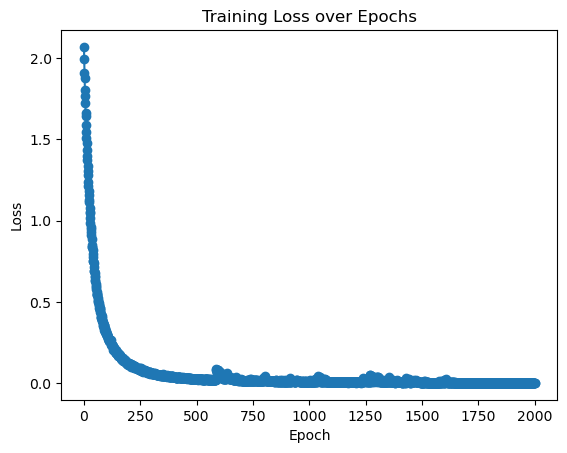

Final training loss: 0.001019820666937321
Training fold 2/precision with params: {'model_params.hidden_layers': (256, 128, 128, 64), 'model_params.activation': 'relu', 'model_params.dropout_rate': 0.1, 'learning_rate': 0.0001, 'batch_size': 128, 'epochs': 2000}
[TorchWrapper] Using device: mps


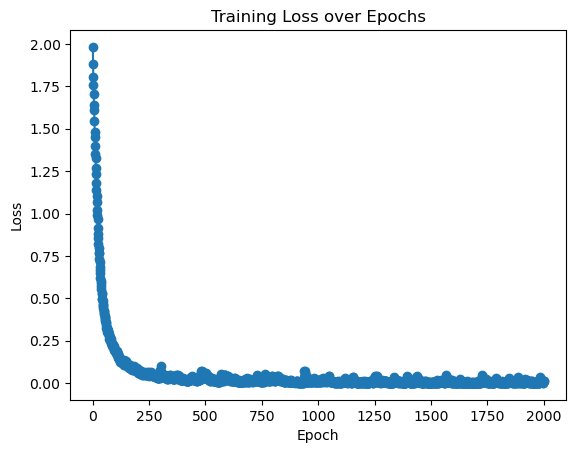

Final training loss: 0.01022760947207697
Training fold 3/precision with params: {'model_params.hidden_layers': (256, 128, 128, 64), 'model_params.activation': 'relu', 'model_params.dropout_rate': 0.1, 'learning_rate': 0.0001, 'batch_size': 128, 'epochs': 2000}
[TorchWrapper] Using device: mps


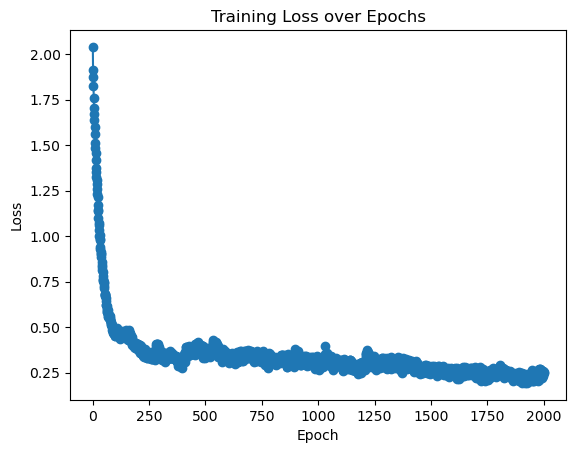

Final training loss: 0.2534840230123806
Training fold 4/precision with params: {'model_params.hidden_layers': (256, 128, 128, 64), 'model_params.activation': 'relu', 'model_params.dropout_rate': 0.1, 'learning_rate': 0.0001, 'batch_size': 128, 'epochs': 2000}
[TorchWrapper] Using device: mps


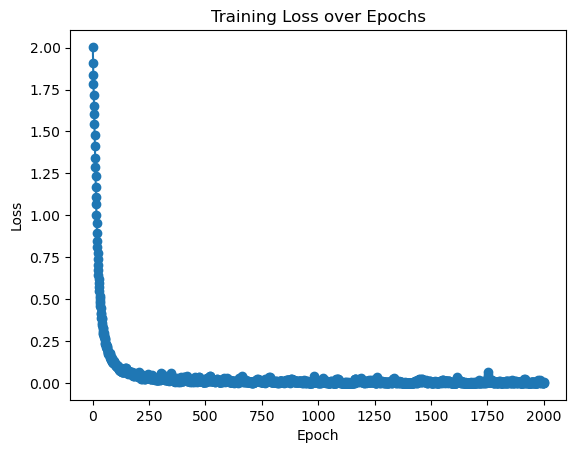

Final training loss: 0.001012386375805363
Training fold 5/precision with params: {'model_params.hidden_layers': (256, 128, 128, 64), 'model_params.activation': 'relu', 'model_params.dropout_rate': 0.1, 'learning_rate': 0.0001, 'batch_size': 128, 'epochs': 2000}
[TorchWrapper] Using device: mps


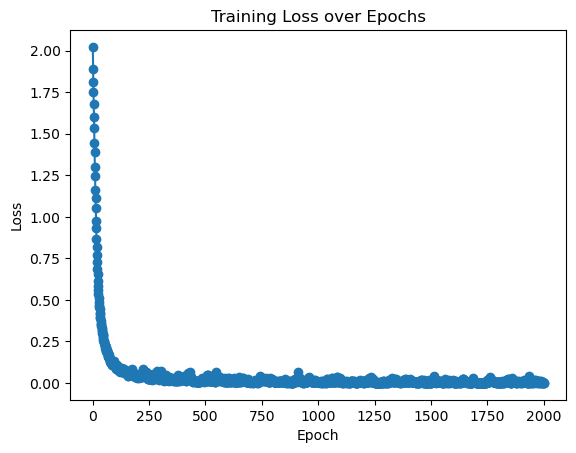

Final training loss: 0.000755824864847444
[TorchWrapper] Using device: mps


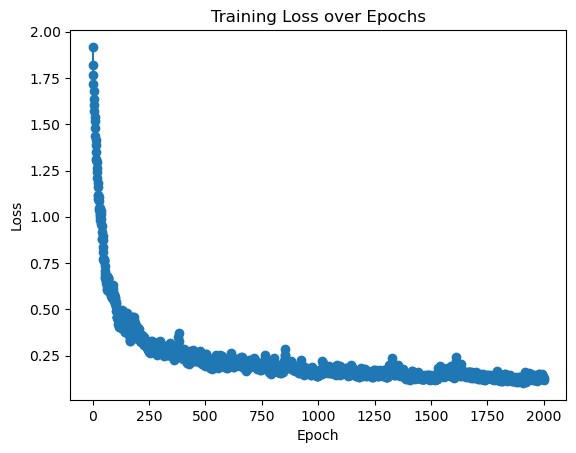

Final training loss: 0.11621671479347853
{'home_goals_train_accuracy': 0.9959064327485379, 'home_goals_train_precision': 0.9683244871070957, 'home_goals_valid_accuracy': 0.2730994152046784, 'home_goals_valid_precision': 0.16122056456260872, 'home_goals_test_accuracy': 0.22807017543859648, 'home_goals_test_precision': 0.15904206064004217, 'home_goals_train_lte_0_accuracy': 0.9974658869395711, 'home_goals_train_lte_0_accuracy_std': 0.0050682261208577105, 'home_goals_train_lte_0_precision': 0.992, 'home_goals_train_lte_0_precision_std': 0.016000000000000014, 'home_goals_train_gt_0_accuracy': 0.9974658869395711, 'home_goals_train_gt_0_accuracy_std': 0.0050682261208577105, 'home_goals_train_gt_0_precision': 0.9994673768308922, 'home_goals_train_gt_0_precision_std': 0.0010652463382156971, 'home_goals_train_gt_1_accuracy': 0.997270955165692, 'home_goals_train_gt_1_accuracy_std': 0.0054580896686160065, 'home_goals_train_gt_1_precision': 1.0, 'home_goals_train_gt_1_precision_std': 0.0, 'home_go

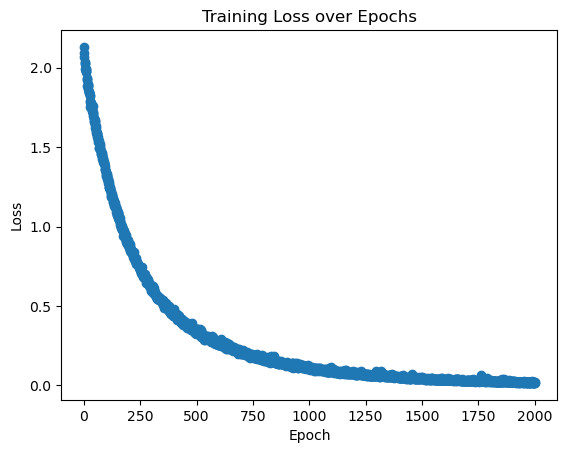

Final training loss: 0.017682707525397603
Training fold 2/5 with params: {'model_params.hidden_layers': (512, 128, 128, 128, 64), 'model_params.activation': 'relu', 'model_params.dropout_rate': 0.1, 'learning_rate': 1e-05, 'batch_size': 64, 'epochs': 2000}
[TorchWrapper] Using device: mps


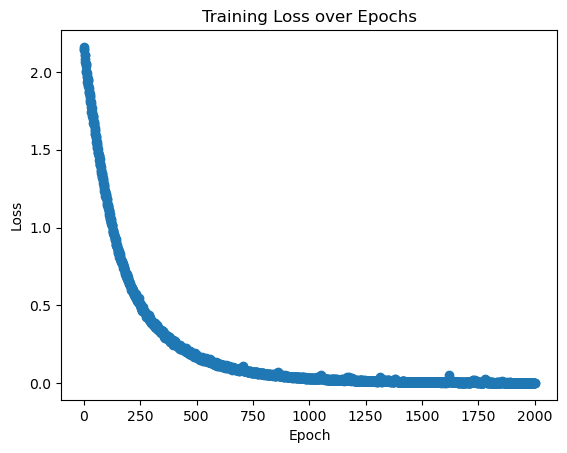

Final training loss: 0.002874158288771559
Training fold 3/5 with params: {'model_params.hidden_layers': (512, 128, 128, 128, 64), 'model_params.activation': 'relu', 'model_params.dropout_rate': 0.1, 'learning_rate': 1e-05, 'batch_size': 64, 'epochs': 2000}
[TorchWrapper] Using device: mps


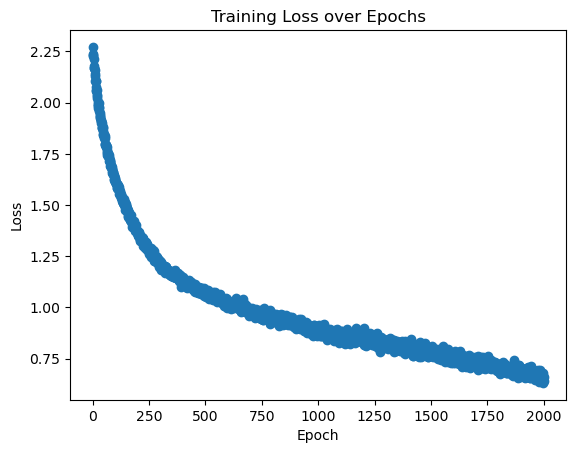

Final training loss: 0.6401849861962986
Training fold 4/5 with params: {'model_params.hidden_layers': (512, 128, 128, 128, 64), 'model_params.activation': 'relu', 'model_params.dropout_rate': 0.1, 'learning_rate': 1e-05, 'batch_size': 64, 'epochs': 2000}
[TorchWrapper] Using device: mps


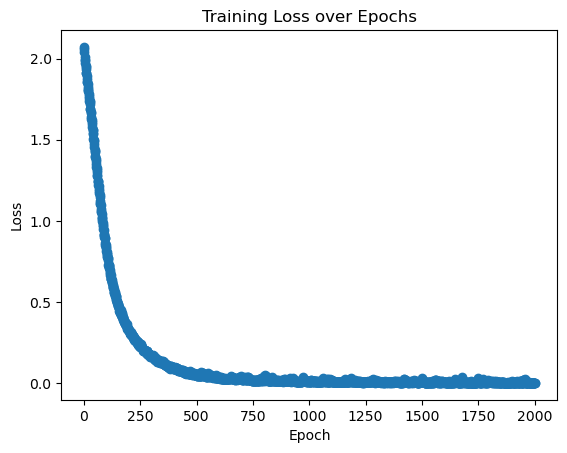

Final training loss: 0.0021183433403310025
Training fold 5/5 with params: {'model_params.hidden_layers': (512, 128, 128, 128, 64), 'model_params.activation': 'relu', 'model_params.dropout_rate': 0.1, 'learning_rate': 1e-05, 'batch_size': 64, 'epochs': 2000}
[TorchWrapper] Using device: mps


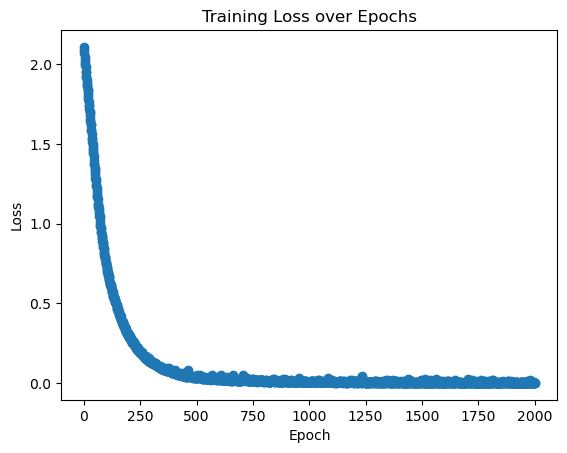

Final training loss: 0.0017411239442486337
[TorchWrapper] Using device: mps


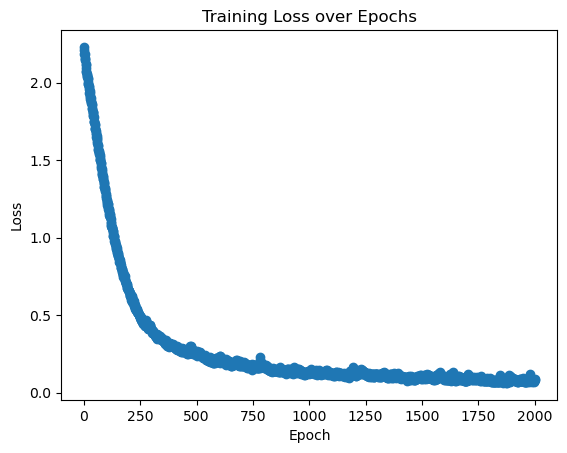

Final training loss: 0.08852225751207586
{'away_goals_train_accuracy': 0.9715399610136451, 'away_goals_train_precision': 0.8875818959234131, 'away_goals_valid_accuracy': 0.3017543859649123, 'away_goals_valid_precision': 0.1421257751757407, 'away_goals_test_accuracy': 0.2412280701754386, 'away_goals_test_precision': 0.1472270305128466, 'away_goals_train_lte_0_accuracy': 0.9941520467836258, 'away_goals_train_lte_0_accuracy_std': 0.008060847223444585, 'away_goals_train_lte_0_precision': 0.9987421383647799, 'away_goals_train_lte_0_precision_std': 0.002515723270440251, 'away_goals_train_gt_0_accuracy': 0.9941520467836258, 'away_goals_train_gt_0_accuracy_std': 0.008060847223444585, 'away_goals_train_gt_0_precision': 0.9921117599582207, 'away_goals_train_gt_0_precision_std': 0.01065781230809308, 'away_goals_train_gt_1_accuracy': 0.9853801169590642, 'away_goals_train_gt_1_accuracy_std': 0.02508492466611372, 'away_goals_train_gt_1_precision': 0.9806241358878136, 'away_goals_train_gt_1_precision

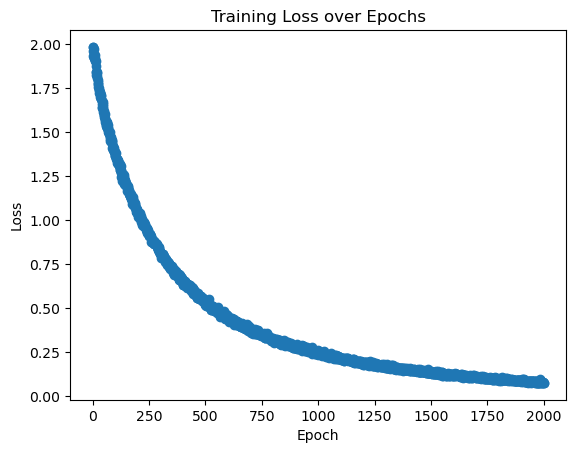

Final training loss: 0.07523086514563589
Training fold 2/precision with params: {'model_params.hidden_layers': (512, 128, 128, 128, 64), 'model_params.activation': 'relu', 'model_params.dropout_rate': 0.1, 'learning_rate': 1e-05, 'batch_size': 128, 'epochs': 2000}
[TorchWrapper] Using device: mps


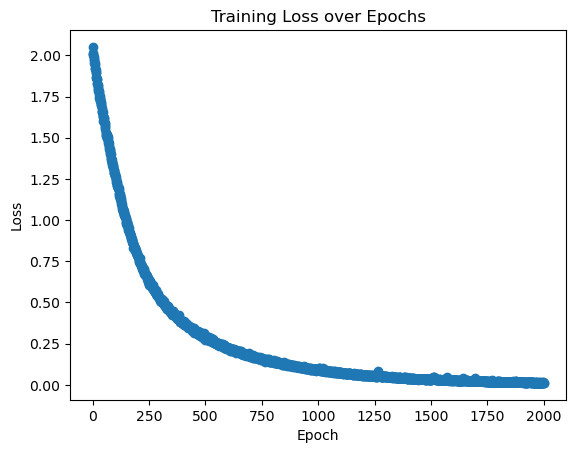

Final training loss: 0.013215176162053968
Training fold 3/precision with params: {'model_params.hidden_layers': (512, 128, 128, 128, 64), 'model_params.activation': 'relu', 'model_params.dropout_rate': 0.1, 'learning_rate': 1e-05, 'batch_size': 128, 'epochs': 2000}
[TorchWrapper] Using device: mps


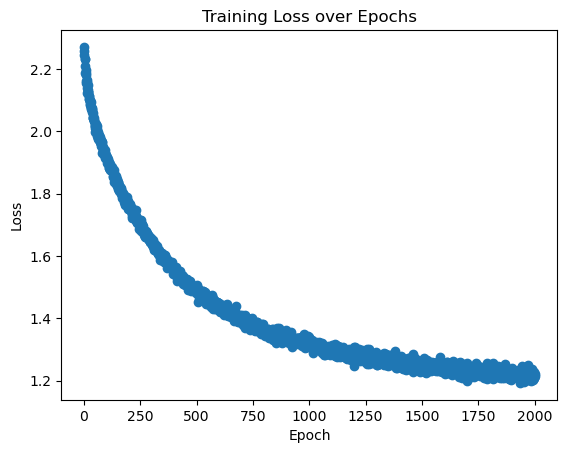

Final training loss: 1.216024182693303
Training fold 4/precision with params: {'model_params.hidden_layers': (512, 128, 128, 128, 64), 'model_params.activation': 'relu', 'model_params.dropout_rate': 0.1, 'learning_rate': 1e-05, 'batch_size': 128, 'epochs': 2000}
[TorchWrapper] Using device: mps


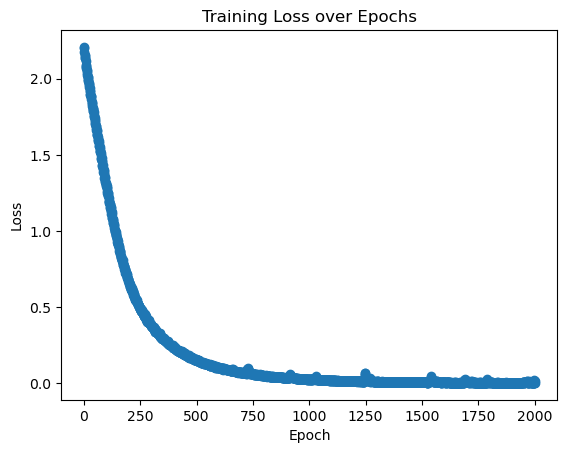

Final training loss: 0.004037419004550977
Training fold 5/precision with params: {'model_params.hidden_layers': (512, 128, 128, 128, 64), 'model_params.activation': 'relu', 'model_params.dropout_rate': 0.1, 'learning_rate': 1e-05, 'batch_size': 128, 'epochs': 2000}
[TorchWrapper] Using device: mps


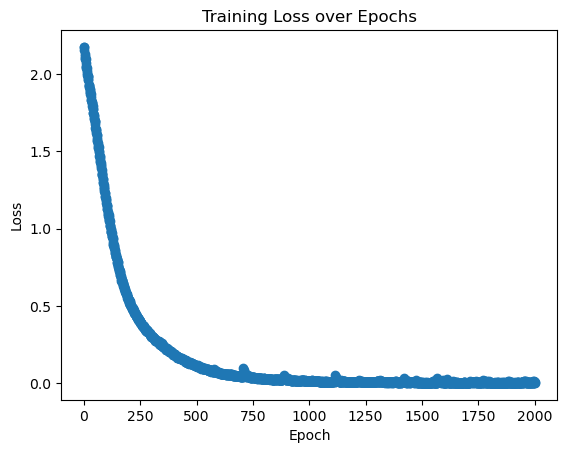

Final training loss: 0.002385290429998211
[TorchWrapper] Using device: mps


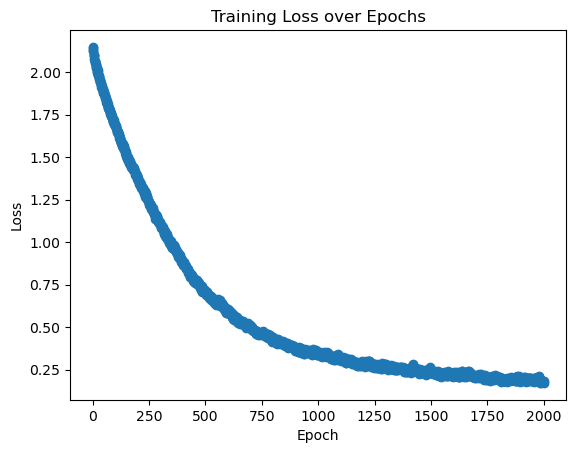

Final training loss: 0.17298240689506308
{'away_goals_train_accuracy': 0.92046783625731, 'away_goals_train_precision': 0.859812680961468, 'away_goals_valid_accuracy': 0.30877192982456136, 'away_goals_valid_precision': 0.13440085463372678, 'away_goals_test_accuracy': 0.2412280701754386, 'away_goals_test_precision': 0.1325105480472011, 'away_goals_train_lte_0_accuracy': 0.9612085769980506, 'away_goals_train_lte_0_accuracy_std': 0.07758284600389863, 'away_goals_train_lte_0_precision': 0.9447368421052632, 'away_goals_train_lte_0_precision_std': 0.11052631578947368, 'away_goals_train_gt_0_accuracy': 0.9612085769980506, 'away_goals_train_gt_0_accuracy_std': 0.07758284600389863, 'away_goals_train_gt_0_precision': 0.9681440443213297, 'away_goals_train_gt_0_precision_std': 0.06371191135734072, 'away_goals_train_gt_1_accuracy': 0.9489278752436647, 'away_goals_train_gt_1_accuracy_std': 0.10214424951267058, 'away_goals_train_gt_1_precision': 0.961111111111111, 'away_goals_train_gt_1_precision_std'

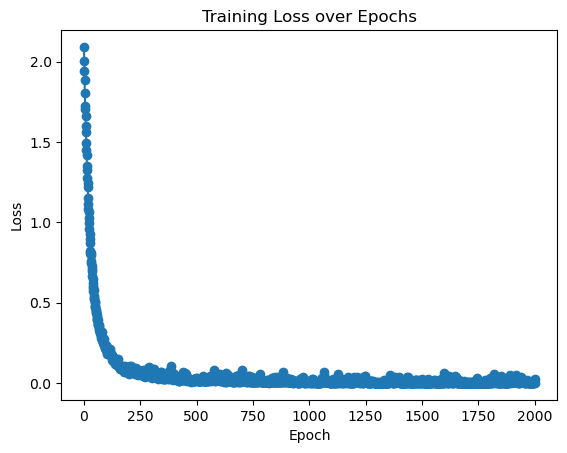

Final training loss: 0.0028411999333933084
Training fold 2/precision with params: {'model_params.hidden_layers': (512, 128, 128, 128, 64), 'model_params.activation': 'relu', 'model_params.dropout_rate': 0.1, 'learning_rate': 0.0001, 'batch_size': 64, 'epochs': 2000}
[TorchWrapper] Using device: mps


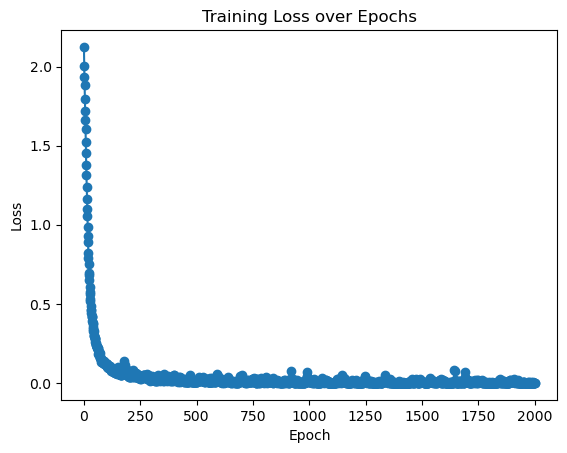

Final training loss: 0.0006238598935101835
Training fold 3/precision with params: {'model_params.hidden_layers': (512, 128, 128, 128, 64), 'model_params.activation': 'relu', 'model_params.dropout_rate': 0.1, 'learning_rate': 0.0001, 'batch_size': 64, 'epochs': 2000}
[TorchWrapper] Using device: mps


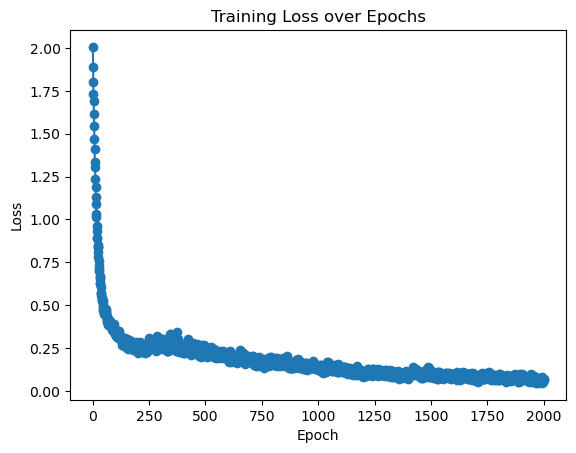

Final training loss: 0.06367618740185892
Training fold 4/precision with params: {'model_params.hidden_layers': (512, 128, 128, 128, 64), 'model_params.activation': 'relu', 'model_params.dropout_rate': 0.1, 'learning_rate': 0.0001, 'batch_size': 64, 'epochs': 2000}
[TorchWrapper] Using device: mps


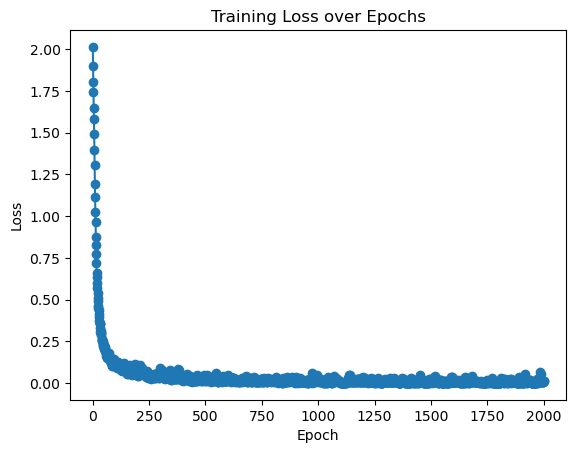

Final training loss: 0.011656357544577785
Training fold 5/precision with params: {'model_params.hidden_layers': (512, 128, 128, 128, 64), 'model_params.activation': 'relu', 'model_params.dropout_rate': 0.1, 'learning_rate': 0.0001, 'batch_size': 64, 'epochs': 2000}
[TorchWrapper] Using device: mps


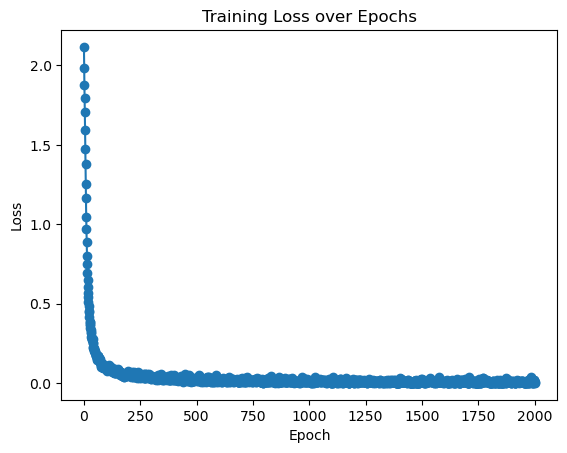

Final training loss: 0.005295950358417648
[TorchWrapper] Using device: mps


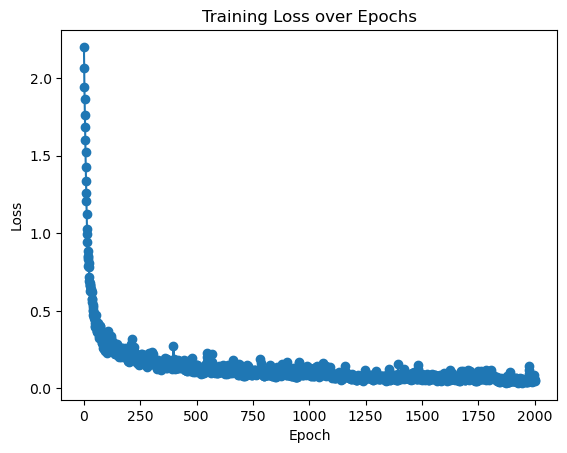

Final training loss: 0.04494309945297055
{'away_goals_train_accuracy': 0.9996101364522417, 'away_goals_train_precision': 0.999766355140187, 'away_goals_valid_accuracy': 0.28070175438596495, 'away_goals_valid_precision': 0.12805667135102722, 'away_goals_test_accuracy': 0.2324561403508772, 'away_goals_test_precision': 0.14081632653061224, 'away_goals_train_lte_0_accuracy': 1.0, 'away_goals_train_lte_0_accuracy_std': 0.0, 'away_goals_train_lte_0_precision': 1.0, 'away_goals_train_lte_0_precision_std': 0.0, 'away_goals_train_gt_0_accuracy': 1.0, 'away_goals_train_gt_0_accuracy_std': 0.0, 'away_goals_train_gt_0_precision': 1.0, 'away_goals_train_gt_0_precision_std': 0.0, 'away_goals_train_gt_1_accuracy': 1.0, 'away_goals_train_gt_1_accuracy_std': 0.0, 'away_goals_train_gt_1_precision': 1.0, 'away_goals_train_gt_1_precision_std': 0.0, 'away_goals_train_gt_2_accuracy': 0.9996101364522417, 'away_goals_train_gt_2_accuracy_std': 0.0007797270955165914, 'away_goals_train_gt_2_precision': 1.0, 'awa

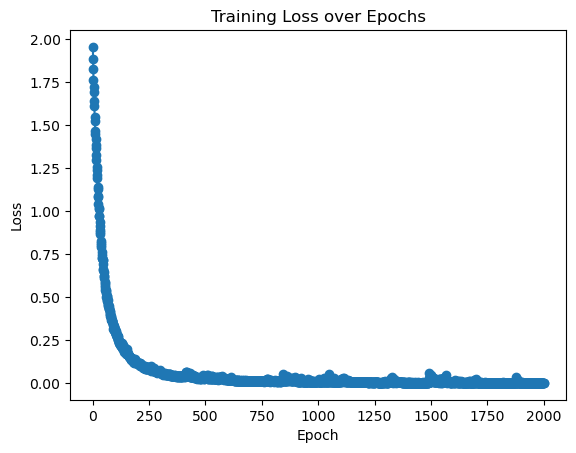

Final training loss: 0.001227371622699351
Training fold 2/precision with params: {'model_params.hidden_layers': (512, 128, 128, 128, 64), 'model_params.activation': 'relu', 'model_params.dropout_rate': 0.1, 'learning_rate': 0.0001, 'batch_size': 128, 'epochs': 2000}
[TorchWrapper] Using device: mps


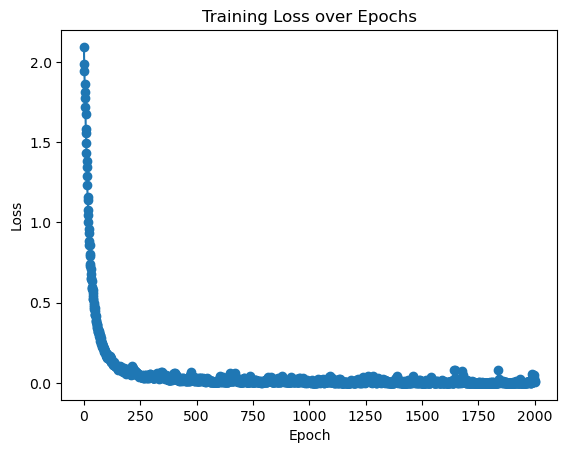

Final training loss: 0.012520936813357978
Training fold 3/precision with params: {'model_params.hidden_layers': (512, 128, 128, 128, 64), 'model_params.activation': 'relu', 'model_params.dropout_rate': 0.1, 'learning_rate': 0.0001, 'batch_size': 128, 'epochs': 2000}
[TorchWrapper] Using device: mps


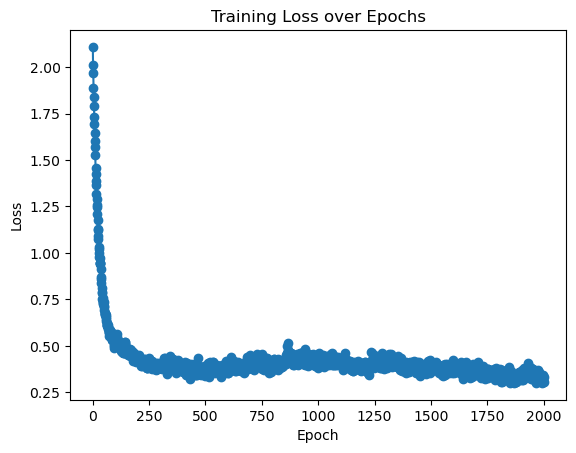

Final training loss: 0.30425808283901584
Training fold 4/precision with params: {'model_params.hidden_layers': (512, 128, 128, 128, 64), 'model_params.activation': 'relu', 'model_params.dropout_rate': 0.1, 'learning_rate': 0.0001, 'batch_size': 128, 'epochs': 2000}
[TorchWrapper] Using device: mps


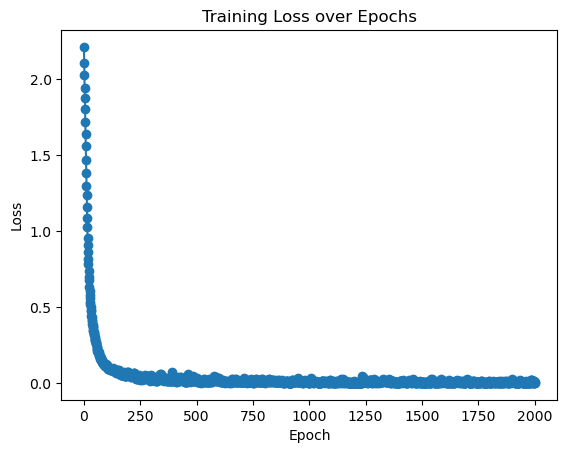

Final training loss: 0.0028942794571712354
Training fold 5/precision with params: {'model_params.hidden_layers': (512, 128, 128, 128, 64), 'model_params.activation': 'relu', 'model_params.dropout_rate': 0.1, 'learning_rate': 0.0001, 'batch_size': 128, 'epochs': 2000}
[TorchWrapper] Using device: mps


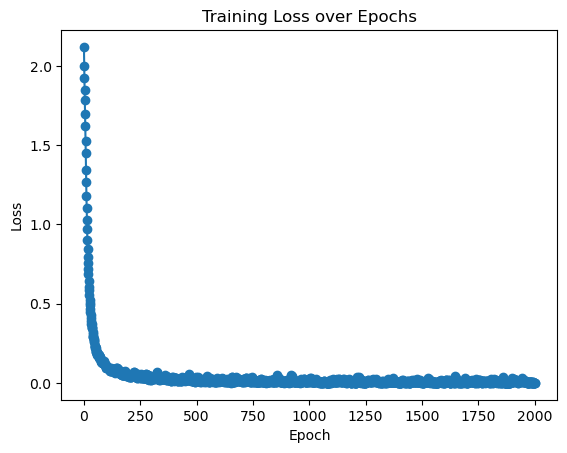

Final training loss: 0.001299902104652808
[TorchWrapper] Using device: mps


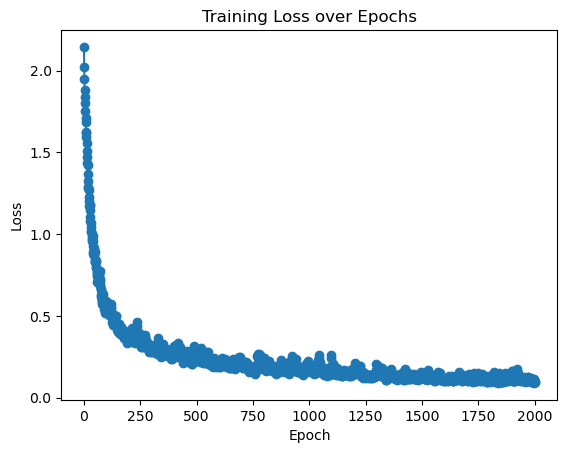

Final training loss: 0.09303349192611887
{'away_goals_train_accuracy': 0.9914230019493179, 'away_goals_train_precision': 0.9354082734345648, 'away_goals_valid_accuracy': 0.29649122807017547, 'away_goals_valid_precision': 0.15013971862381648, 'away_goals_test_accuracy': 0.25, 'away_goals_test_precision': 0.13431878894063767, 'away_goals_train_lte_0_accuracy': 0.996101364522417, 'away_goals_train_lte_0_accuracy_std': 0.007797270955165692, 'away_goals_train_lte_0_precision': 0.992375366568915, 'away_goals_train_lte_0_precision_std': 0.015249266862170076, 'away_goals_train_gt_0_accuracy': 0.996101364522417, 'away_goals_train_gt_0_accuracy_std': 0.007797270955165692, 'away_goals_train_gt_0_precision': 0.9979562043795621, 'away_goals_train_gt_0_precision_std': 0.004087591240875899, 'away_goals_train_gt_1_accuracy': 0.9951267056530215, 'away_goals_train_gt_1_accuracy_std': 0.009746588693957125, 'away_goals_train_gt_1_precision': 0.9958702064896755, 'away_goals_train_gt_1_precision_std': 0.008

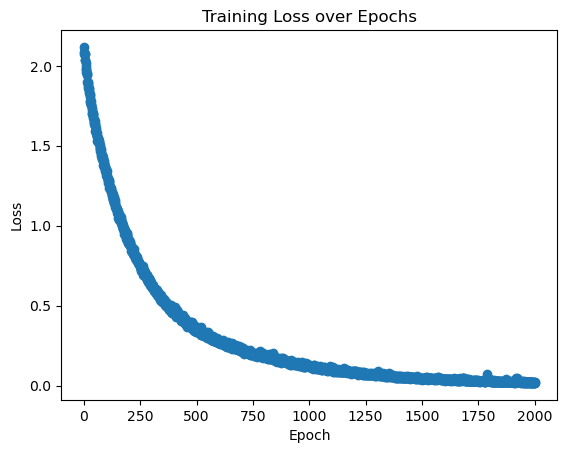

Final training loss: 0.01828995061635274
Training fold 2/precision with params: {'model_params.hidden_layers': (256, 128, 128, 64), 'model_params.activation': 'relu', 'model_params.dropout_rate': 0.1, 'learning_rate': 1e-05, 'batch_size': 64, 'epochs': 2000}
[TorchWrapper] Using device: mps


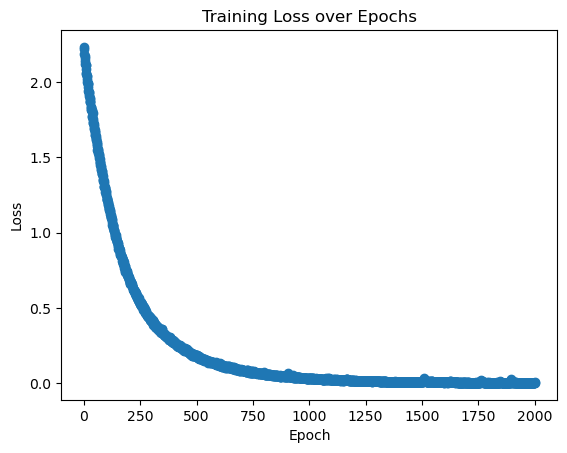

Final training loss: 0.0021431494425241536
Training fold 3/precision with params: {'model_params.hidden_layers': (256, 128, 128, 64), 'model_params.activation': 'relu', 'model_params.dropout_rate': 0.1, 'learning_rate': 1e-05, 'batch_size': 64, 'epochs': 2000}
[TorchWrapper] Using device: mps


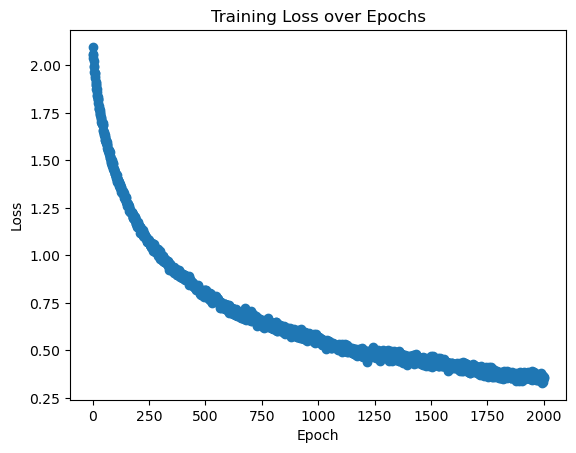

Final training loss: 0.36038959386520686
Training fold 4/precision with params: {'model_params.hidden_layers': (256, 128, 128, 64), 'model_params.activation': 'relu', 'model_params.dropout_rate': 0.1, 'learning_rate': 1e-05, 'batch_size': 64, 'epochs': 2000}
[TorchWrapper] Using device: mps


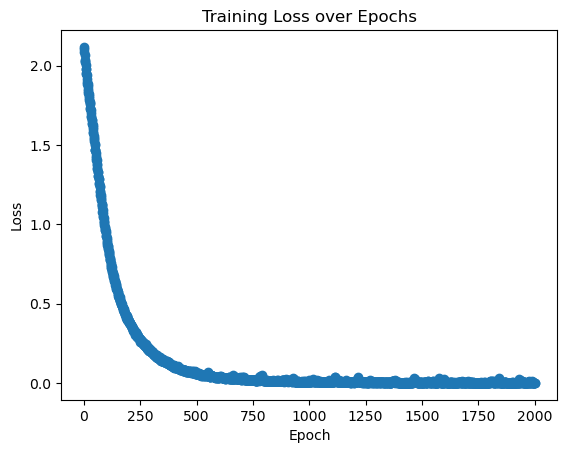

Final training loss: 0.0015994855842678345
Training fold 5/precision with params: {'model_params.hidden_layers': (256, 128, 128, 64), 'model_params.activation': 'relu', 'model_params.dropout_rate': 0.1, 'learning_rate': 1e-05, 'batch_size': 64, 'epochs': 2000}
[TorchWrapper] Using device: mps


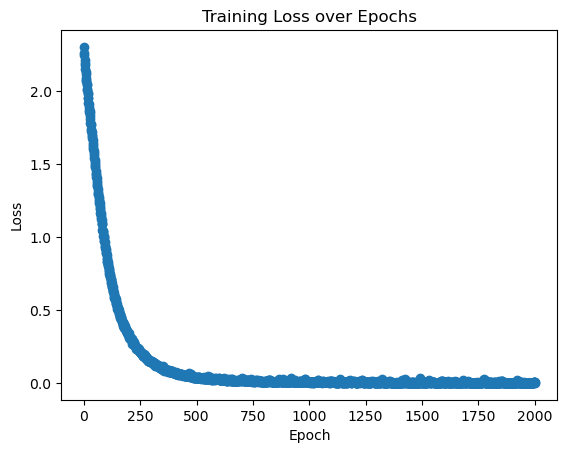

Final training loss: 0.0029262161922602972
[TorchWrapper] Using device: mps


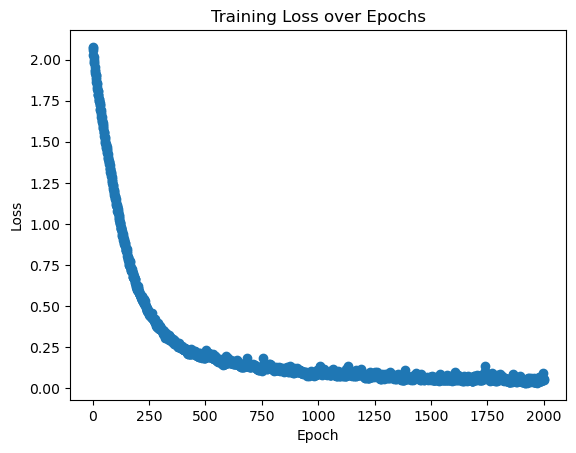

Final training loss: 0.053901192882837144
{'away_goals_train_accuracy': 0.9900584795321639, 'away_goals_train_precision': 0.9448783596475631, 'away_goals_valid_accuracy': 0.29473684210526313, 'away_goals_valid_precision': 0.15810458767082367, 'away_goals_test_accuracy': 0.3026315789473684, 'away_goals_test_precision': 0.19876994823086466, 'away_goals_train_lte_0_accuracy': 0.997270955165692, 'away_goals_train_lte_0_accuracy_std': 0.0054580896686160065, 'away_goals_train_lte_0_precision': 0.991977077363897, 'away_goals_train_lte_0_precision_std': 0.016045845272206316, 'away_goals_train_gt_0_accuracy': 0.997270955165692, 'away_goals_train_gt_0_accuracy_std': 0.0054580896686160065, 'away_goals_train_gt_0_precision': 1.0, 'away_goals_train_gt_0_precision_std': 0.0, 'away_goals_train_gt_1_accuracy': 0.9933723196881091, 'away_goals_train_gt_1_accuracy_std': 0.013255360623781699, 'away_goals_train_gt_1_precision': 1.0, 'away_goals_train_gt_1_precision_std': 0.0, 'away_goals_train_gt_2_accurac

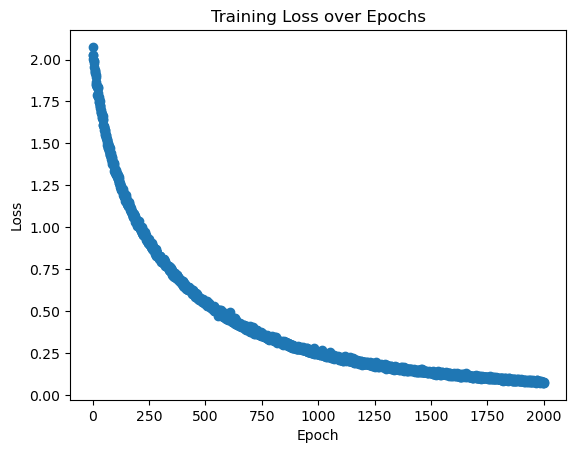

Final training loss: 0.07326169264072563
Training fold 2/precision with params: {'model_params.hidden_layers': (256, 128, 128, 64), 'model_params.activation': 'relu', 'model_params.dropout_rate': 0.1, 'learning_rate': 1e-05, 'batch_size': 128, 'epochs': 2000}
[TorchWrapper] Using device: mps


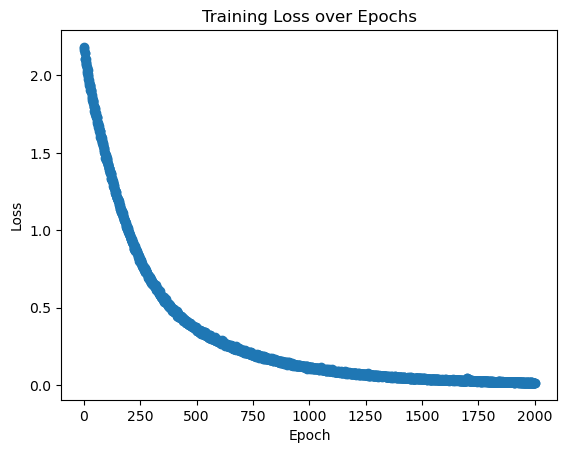

Final training loss: 0.015857473560418302
Training fold 3/precision with params: {'model_params.hidden_layers': (256, 128, 128, 64), 'model_params.activation': 'relu', 'model_params.dropout_rate': 0.1, 'learning_rate': 1e-05, 'batch_size': 128, 'epochs': 2000}
[TorchWrapper] Using device: mps


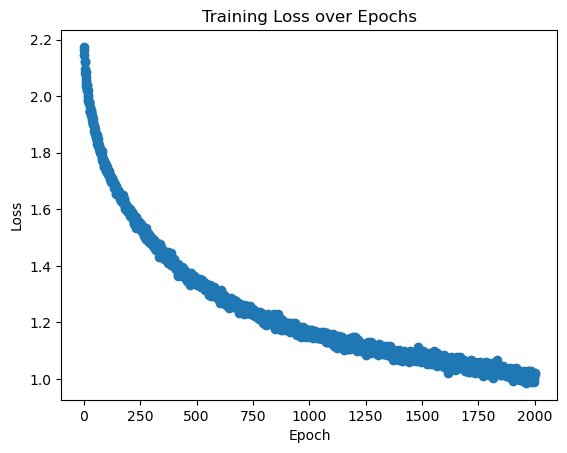

Final training loss: 1.0158074650383366
Training fold 4/precision with params: {'model_params.hidden_layers': (256, 128, 128, 64), 'model_params.activation': 'relu', 'model_params.dropout_rate': 0.1, 'learning_rate': 1e-05, 'batch_size': 128, 'epochs': 2000}
[TorchWrapper] Using device: mps


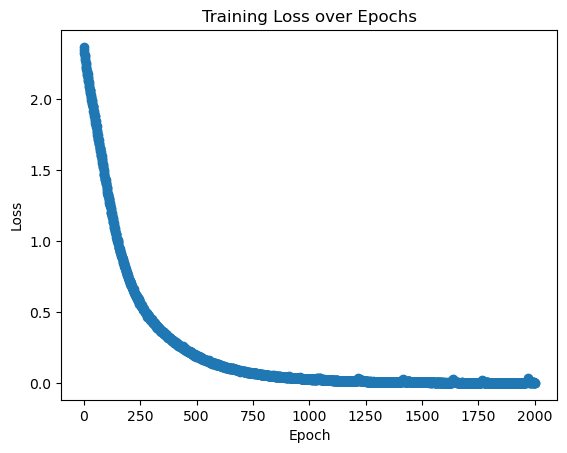

Final training loss: 0.002498058482394581
Training fold 5/precision with params: {'model_params.hidden_layers': (256, 128, 128, 64), 'model_params.activation': 'relu', 'model_params.dropout_rate': 0.1, 'learning_rate': 1e-05, 'batch_size': 128, 'epochs': 2000}
[TorchWrapper] Using device: mps


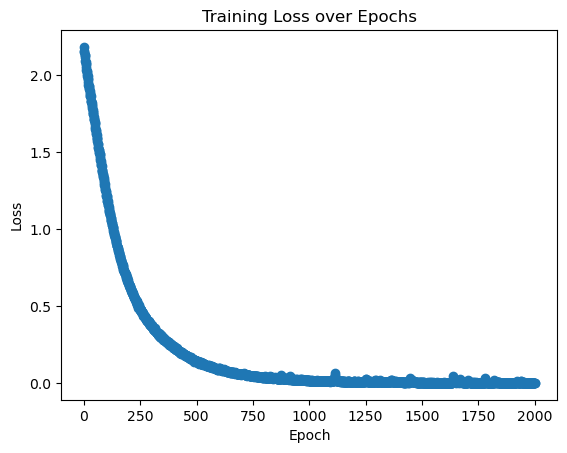

Final training loss: 0.002059050586227088
[TorchWrapper] Using device: mps


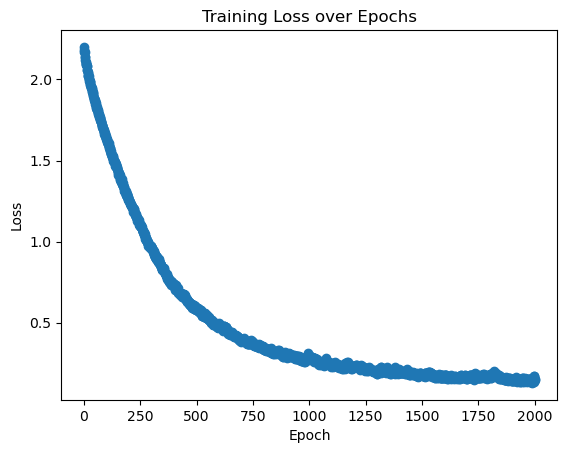

Final training loss: 0.14752821615564893
{'away_goals_train_accuracy': 0.9545808966861598, 'away_goals_train_precision': 0.8793106966524367, 'away_goals_valid_accuracy': 0.2994152046783626, 'away_goals_valid_precision': 0.15009225074947785, 'away_goals_test_accuracy': 0.22807017543859648, 'away_goals_test_precision': 0.1663380098162707, 'away_goals_train_lte_0_accuracy': 0.9810916179337232, 'away_goals_train_lte_0_accuracy_std': 0.03781676413255362, 'away_goals_train_lte_0_precision': 0.9636363636363636, 'away_goals_train_lte_0_precision_std': 0.0727272727272727, 'away_goals_train_gt_0_accuracy': 0.9810916179337232, 'away_goals_train_gt_0_accuracy_std': 0.03781676413255362, 'away_goals_train_gt_0_precision': 0.9911042944785275, 'away_goals_train_gt_0_precision_std': 0.017791411042944773, 'away_goals_train_gt_1_accuracy': 0.9709551656920077, 'away_goals_train_gt_1_accuracy_std': 0.05808966861598441, 'away_goals_train_gt_1_precision': 0.986266094420601, 'away_goals_train_gt_1_precision_s

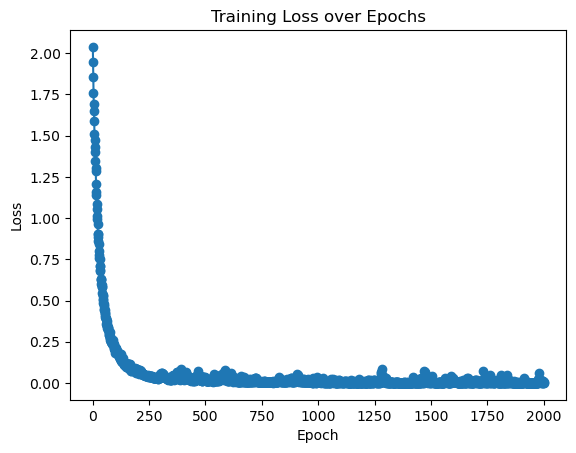

Final training loss: 0.003162667253299763
Training fold 2/precision with params: {'model_params.hidden_layers': (256, 128, 128, 64), 'model_params.activation': 'relu', 'model_params.dropout_rate': 0.1, 'learning_rate': 0.0001, 'batch_size': 64, 'epochs': 2000}
[TorchWrapper] Using device: mps


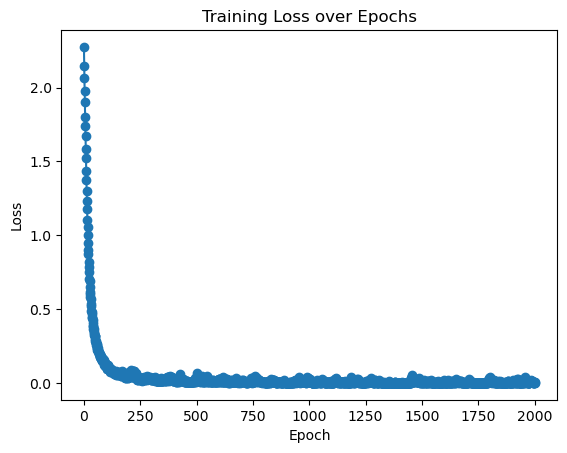

Final training loss: 0.0032831437331597097
Training fold 3/precision with params: {'model_params.hidden_layers': (256, 128, 128, 64), 'model_params.activation': 'relu', 'model_params.dropout_rate': 0.1, 'learning_rate': 0.0001, 'batch_size': 64, 'epochs': 2000}
[TorchWrapper] Using device: mps


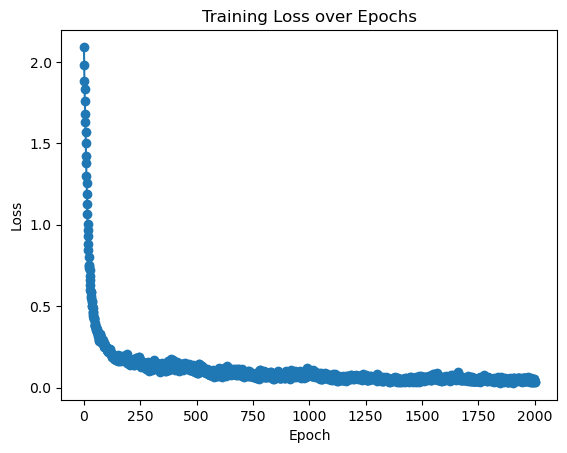

Final training loss: 0.03555253920731721
Training fold 4/precision with params: {'model_params.hidden_layers': (256, 128, 128, 64), 'model_params.activation': 'relu', 'model_params.dropout_rate': 0.1, 'learning_rate': 0.0001, 'batch_size': 64, 'epochs': 2000}
[TorchWrapper] Using device: mps


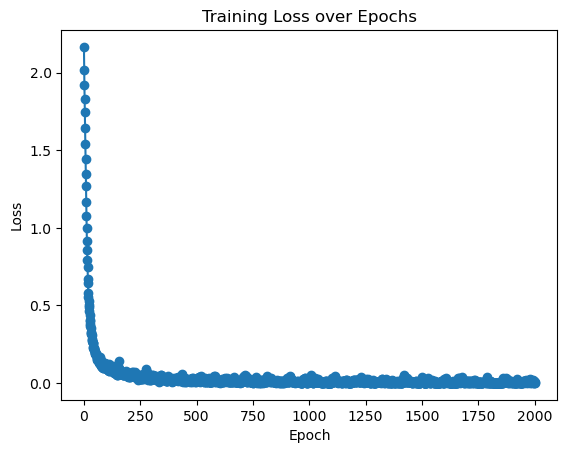

Final training loss: 0.0018852251249621486
Training fold 5/precision with params: {'model_params.hidden_layers': (256, 128, 128, 64), 'model_params.activation': 'relu', 'model_params.dropout_rate': 0.1, 'learning_rate': 0.0001, 'batch_size': 64, 'epochs': 2000}
[TorchWrapper] Using device: mps


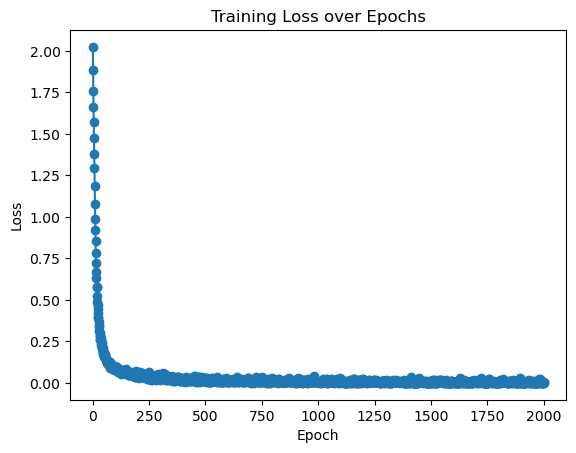

Final training loss: 0.0024032664030847516
[TorchWrapper] Using device: mps


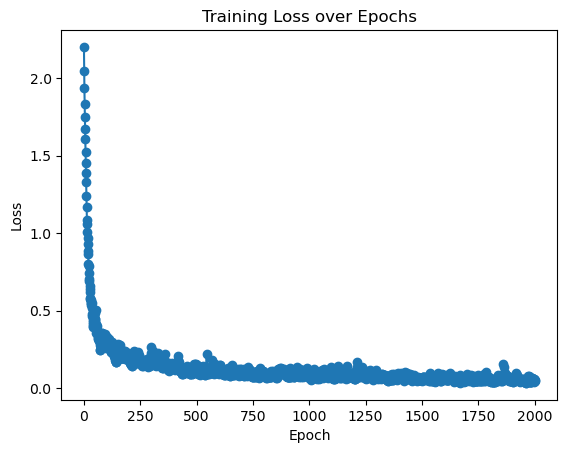

Final training loss: 0.047584522304943894
{'away_goals_train_accuracy': 1.0, 'away_goals_train_precision': 1.0, 'away_goals_valid_accuracy': 0.30292397660818715, 'away_goals_valid_precision': 0.16217074838837917, 'away_goals_test_accuracy': 0.21929824561403508, 'away_goals_test_precision': 0.11368195629900313, 'away_goals_train_lte_0_accuracy': 1.0, 'away_goals_train_lte_0_accuracy_std': 0.0, 'away_goals_train_lte_0_precision': 1.0, 'away_goals_train_lte_0_precision_std': 0.0, 'away_goals_train_gt_0_accuracy': 1.0, 'away_goals_train_gt_0_accuracy_std': 0.0, 'away_goals_train_gt_0_precision': 1.0, 'away_goals_train_gt_0_precision_std': 0.0, 'away_goals_train_gt_1_accuracy': 1.0, 'away_goals_train_gt_1_accuracy_std': 0.0, 'away_goals_train_gt_1_precision': 1.0, 'away_goals_train_gt_1_precision_std': 0.0, 'away_goals_train_gt_2_accuracy': 1.0, 'away_goals_train_gt_2_accuracy_std': 0.0, 'away_goals_train_gt_2_precision': 1.0, 'away_goals_train_gt_2_precision_std': 0.0, 'away_goals_train_gt

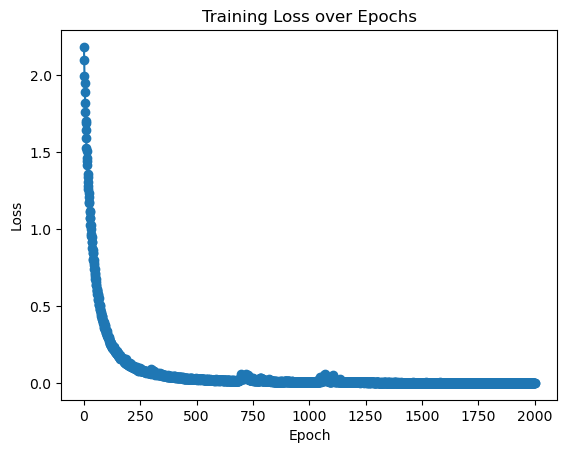

Final training loss: 0.0009576224303962282
Training fold 2/precision with params: {'model_params.hidden_layers': (256, 128, 128, 64), 'model_params.activation': 'relu', 'model_params.dropout_rate': 0.1, 'learning_rate': 0.0001, 'batch_size': 128, 'epochs': 2000}
[TorchWrapper] Using device: mps


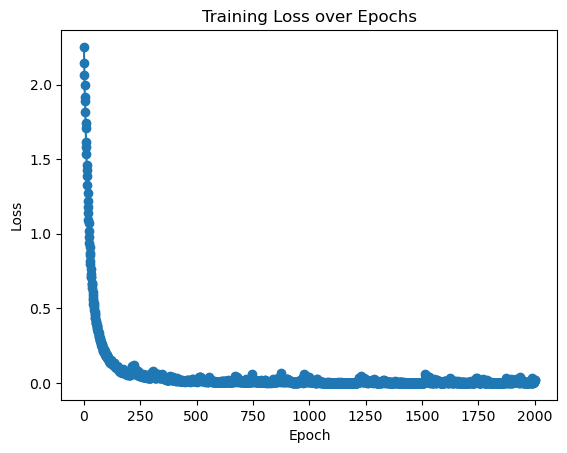

Final training loss: 0.022253998958271497
Training fold 3/precision with params: {'model_params.hidden_layers': (256, 128, 128, 64), 'model_params.activation': 'relu', 'model_params.dropout_rate': 0.1, 'learning_rate': 0.0001, 'batch_size': 128, 'epochs': 2000}
[TorchWrapper] Using device: mps


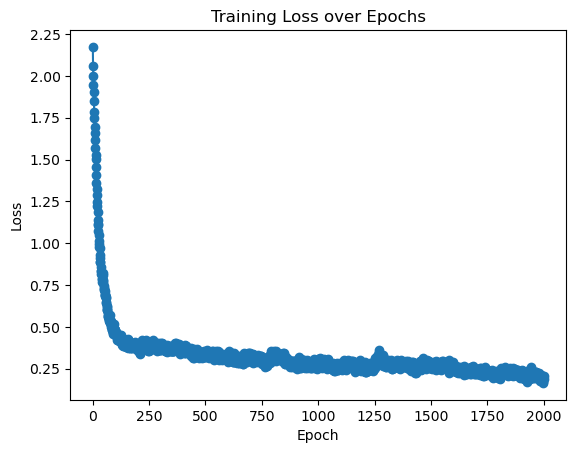

Final training loss: 0.1875848426223963
Training fold 4/precision with params: {'model_params.hidden_layers': (256, 128, 128, 64), 'model_params.activation': 'relu', 'model_params.dropout_rate': 0.1, 'learning_rate': 0.0001, 'batch_size': 128, 'epochs': 2000}
[TorchWrapper] Using device: mps


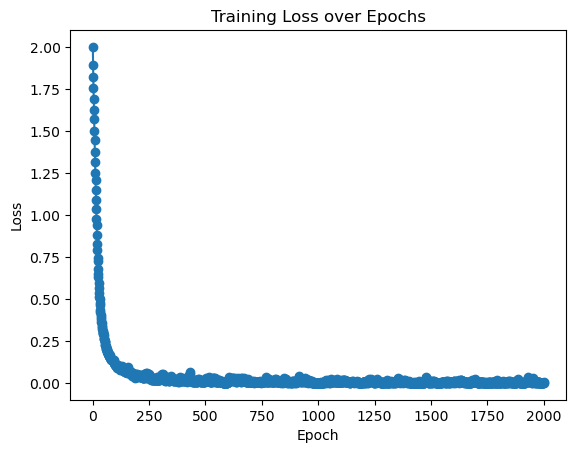

Final training loss: 0.0005387036566900319
Training fold 5/precision with params: {'model_params.hidden_layers': (256, 128, 128, 64), 'model_params.activation': 'relu', 'model_params.dropout_rate': 0.1, 'learning_rate': 0.0001, 'batch_size': 128, 'epochs': 2000}
[TorchWrapper] Using device: mps


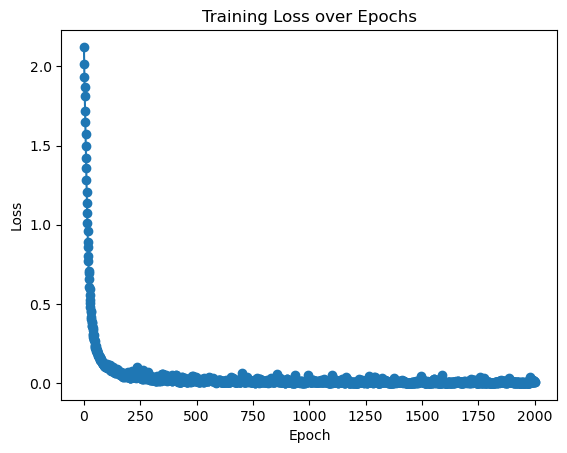

Final training loss: 0.005370758948316634
[TorchWrapper] Using device: mps


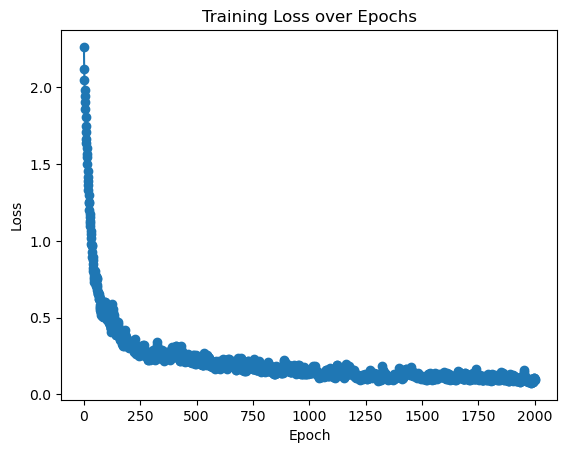

Final training loss: 0.09427373241959956
{'away_goals_train_accuracy': 0.9962962962962962, 'away_goals_train_precision': 0.9457677684768185, 'away_goals_valid_accuracy': 0.29824561403508776, 'away_goals_valid_precision': 0.17908809727890257, 'away_goals_test_accuracy': 0.21052631578947367, 'away_goals_test_precision': 0.10275920974450387, 'away_goals_train_lte_0_accuracy': 0.9980506822612085, 'away_goals_train_lte_0_accuracy_std': 0.003898635477582868, 'away_goals_train_lte_0_precision': 0.9947521865889213, 'away_goals_train_lte_0_precision_std': 0.010495626822157435, 'away_goals_train_gt_0_accuracy': 0.9980506822612085, 'away_goals_train_gt_0_accuracy_std': 0.003898635477582868, 'away_goals_train_gt_0_precision': 0.9997071742313324, 'away_goals_train_gt_0_precision_std': 0.0005856515373352966, 'away_goals_train_gt_1_accuracy': 0.9984405458089668, 'away_goals_train_gt_1_accuracy_std': 0.0031189083820662767, 'away_goals_train_gt_1_precision': 1.0, 'away_goals_train_gt_1_precision_std': 

In [9]:

run_multiclass_distribution_experiment(
    feature_df=feature_df,
    target_df=target_df,
    target_ranges=TRAINGING_CONFIG['target_ranges'],
    model_wrapper_class=lambda **params: TorchWrapper(
        model_class=MLPWithDropoutBN,
        model_params={k.replace('model_params.', ''): v for k, v in params.items() if k.startswith('model_params.')},
        learning_rate=params.get('learning_rate', 0.001),
        batch_size=params.get('batch_size', 64),
        epochs=params.get('epochs', 20)
    ),
    model_param_grid=param_grid,
    test_size=TRAINGING_CONFIG['test_size'],
    k=5,
    experiment_name=TRAINGING_CONFIG['experiment_name'],
    uri=f'{REPO_PATH}/mlflow',
    model_name='MLPwithDropoutBN',
    key_columns=TRAINGING_CONFIG['key_columns'],
)

/Users/tianqihuang/Documents/GitHub/betbot/src/model/experiment_utils.py:126: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


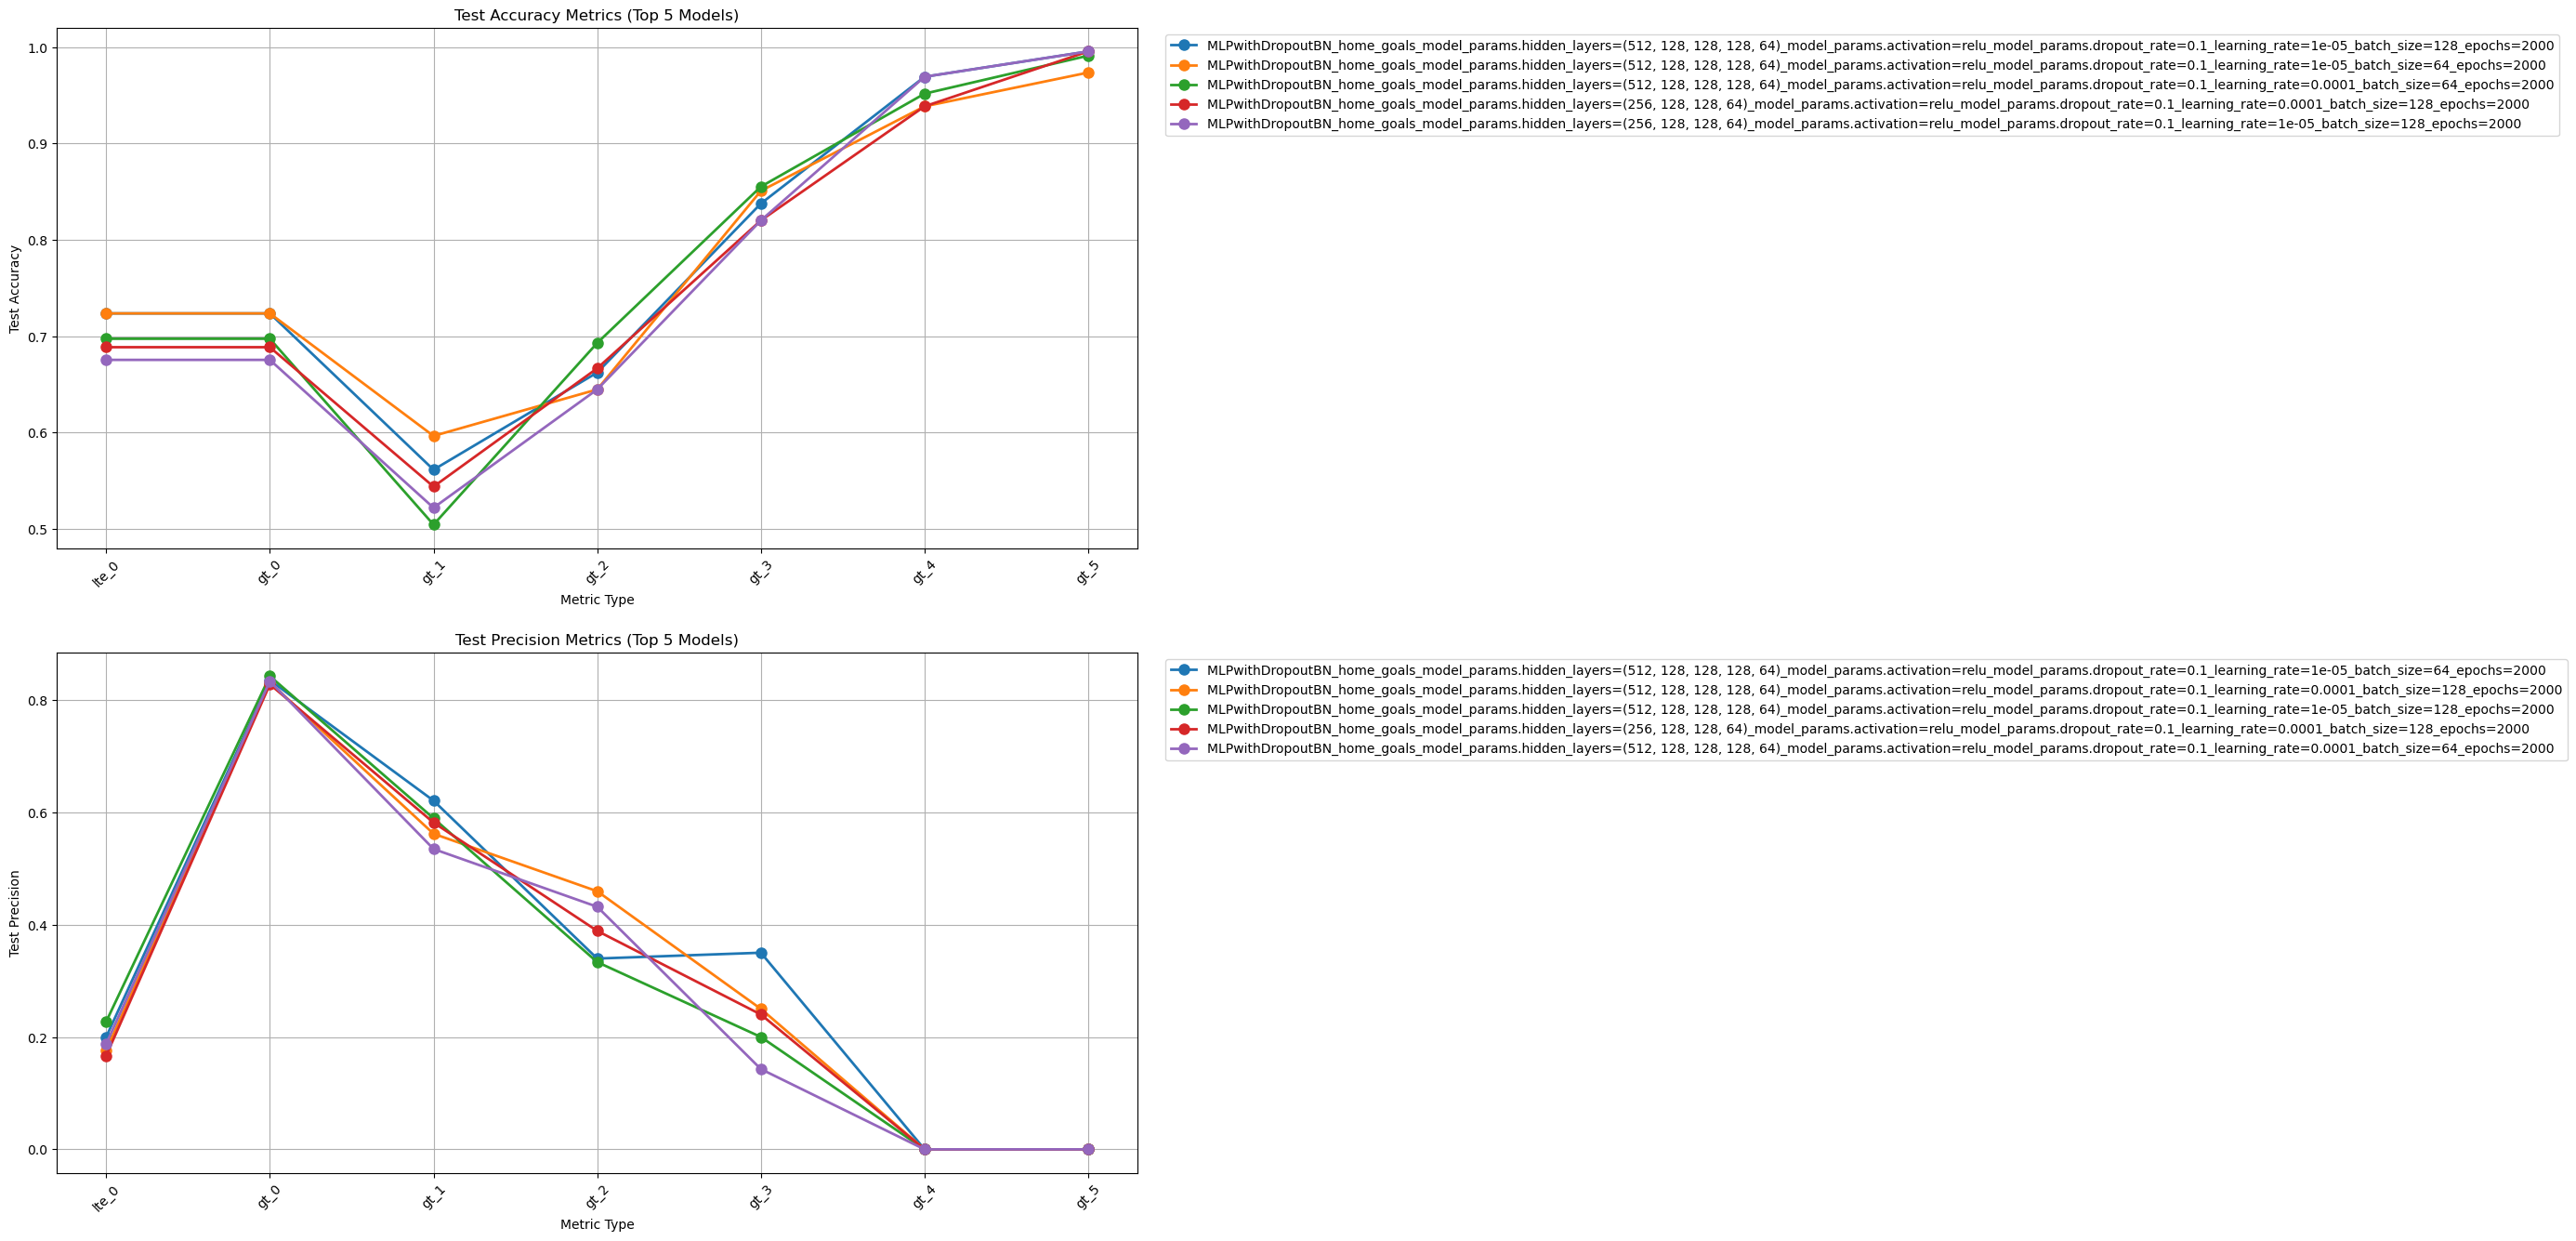

In [10]:
plot_metrics_for_target_and_model(
    experiment_name=TRAINGING_CONFIG['experiment_name'],
    target_col="home_goals",
    model_name="MLPwithDropoutBN",
    tracking_uri=f"{REPO_PATH}/mlflow"
)

In [11]:
plot_run_metrics_by_split(experiment_name=TRAINGING_CONFIG['experiment_name'],
                         run_name="MLPwithDropoutBN_away_goals_{'model_params.hidden_layers': (512, 256, 256, 128, 128), 'model_params.activation': 'relu', 'model_params.dropout_rate': 0, 'learning_rate': 1e-05, 'batch_size': 64, 'epochs': 5000}",
                         target_col="home_goals",
                         tracking_uri=f"{REPO_PATH}/mlflow")

MlflowException: Invalid clause(s) in filter string: 'tags.mlflow.runName = 'MLPwithDropoutBN_away_goals_{'model_params.hidden_layers', '': (512, 256, 256, 128, 128), '', 'model_params.activation', '': '', 'relu', '', '', 'model_params.dropout_rate', '': 0, '', 'learning_rate', '': 1e-05, '', 'batch_size', '': 64, '', 'epochs', '': 5000}''

In [ ]:
plot_run_metrics_side_by_side(experiment_name=TRAINGING_CONFIG['experiment_name'],
                              model_name="MLPwithDropoutBN",
                              model_param={'model_params.hidden_layers': (512, 256, 256, 128, 128), 'model_params.activation': 'relu', 'model_params.dropout_rate': 0, 'learning_rate': 0.00001, 'batch_size': 64, 'epochs': 5000},
                              tracking_uri=f"{REPO_PATH}/mlflow",
                              metric_type="precision")

Searching for runs with filter: params.model_name = 'MLPwithDropoutBN' and params.model_params.hidden_layers: '(512, 256, 256, 128, 128)' and params.model_params.activation: 'relu' and params.model_params.dropout_rate: '0' and params.learning_rate: '1e-05' and params.batch_size: '64' and params.epochs: '5000'


MlflowException: Invalid clause(s) in filter string: 'params.model_params.hidden_layers', ':', ''(512, 256, 256, 128, 128)'', 'params.model_params.activation', ':', ''relu'', 'params.model_params.dropout_rate', ':', ''0'', 'params.learning_rate', ':', ''1e-05'', 'params.batch_size', ':', ''64'', 'params.epochs', ':', ''5000''